<span style="color:red; font-size:28px;">Environment Setup and Configuration</span>

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import random
import os
import warnings
from pandas.errors import SettingWithCopyWarning

In [2]:
# set this project config to help check codes more convenient
class ProjectConfig:
    # centralized management of paths, parameters, and mapping relationships

    # the seeds to ensure the repeat of results
    RANDOM_SEED = 42
    
    # degur mode due to huge datasets
    DEBUG_MODE = False
    
    if DEBUG_MODE:
        MAX_EPOCHS = 3
        PATIENCE = 2
    else:
        MAX_EPOCHS = 40 
        PATIENCE = 40
        
    DEBUG_ROWS = 3000
    DEBUG_WELLS = 15
    
    # Data cleaning threshold under normal mode
    MIN_SAMPLES_PER_WELL = 500
    
    # path settings
    DATA_DIR = "../data"      
    FIGURE_DIR_P1 = "../figures/data_plot" 
    FIGURE_DIR_P2 = "../figures/model_plot" 
    MODEL_DIR = "../saved_models"       
    REPORT_DIR = "../reports"
    
    # the dataset name
    TRAIN_FILE = "main_train.csv"  
    TEST_FILE = "test.xlsx"       
    
    # for all those items whose names contain these keywords (such as RDEP or RDEP_1), these will perform Log processing on them later
    RESISTIVITY_KEYWORDS = ['RDEP', 'RMED', 'RSHA', 'RXO']
    
    # Tarim dataset mapping preset 
    TARIM_RENAME_MAP = {
        'AC': 'DTC', 'DT': 'DTC',
        'DEN': 'RHOB', 'ZDEN': 'RHOB',
        'CNL': 'NPHI', 'CNC': 'NPHI',
        'GR': 'GR', 'GAM': 'GR',
        'RT': 'RDEP', 'RD': 'RDEP', 'RES': 'RDEP'
    }
    
    # plot settings
    FIG_DPI = 200 if DEBUG_MODE else 600
    FONT_SIZE = 20

config = ProjectConfig()

def check_directories():
    # automatically create all the necessary subfolders
    dirs_to_make = [
        config.FIGURE_DIR_P1, 
        config.FIGURE_DIR_P2, 
        config.MODEL_DIR, 
        config.REPORT_DIR
    ]
    for d in dirs_to_make:
        if not os.path.exists(d):
            os.makedirs(d)
            print(f"Created directory: {d}")
        else:
            print(f"Directory found: {d}")

check_directories()

# warning management which is to maintain the neatness of the log output, non-critical Pandas warnings were suppressed, and the focus was placed on the actual error messages
warnings.filterwarnings("ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Directory found: ../figures/data_plot
Directory found: ../figures/model_plot
Directory found: ../saved_models
Directory found: ../reports


In [3]:
# to summarize some functions that often used in the following cell part to better check the functions
# this function is to ensure the reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

def setup_plotting_style():
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.size': config.FONT_SIZE,
        'axes.labelsize': config.FONT_SIZE,
        'axes.titlesize': config.FONT_SIZE + 2,
        'xtick.labelsize': config.FONT_SIZE - 2,
        'ytick.labelsize': config.FONT_SIZE - 2,
        'legend.fontsize': config.FONT_SIZE - 2,
        'figure.dpi': config.FIG_DPI,
        'figure.figsize': (12, 8),
        'lines.linewidth': 2.5,
        'savefig.dpi': 600,       
        'savefig.bbox': 'tight'   
    })

In [4]:
# initialize the functions
seed_everything(config.RANDOM_SEED)
setup_plotting_style()
check_directories()
rng = np.random.default_rng(config.RANDOM_SEED)

print(f"Environment Setup Complete.")
print(f"Currently, this is the Mode: {'DEBUG' if config.DEBUG_MODE else 'PRODUCTION'}")

Directory found: ../figures/data_plot
Directory found: ../figures/model_plot
Directory found: ../saved_models
Directory found: ../reports
Environment Setup Complete.
Currently, this is the Mode: PRODUCTION


<span style="color:red; font-size:28px;">Data Loading</span>

In [5]:
# define the expected column to only focus on needed columns in this project to avoid spatial Leakage and save memory
desired_cols = [
    'WELL', 'DEPTH_MD', 
    'GR', 'RHOB', 'NPHI', 'PEF', 'DTC',       
    'RDEP', 'SP', 'CALI', 'DRHO', 
    'RMED', 'RSHA', 'SGR', 'DTS',
    'FORCE_2020_LITHOFACIES_LITHOLOGY',       
    'FORCE_2020_LITHOFACIES_CONFIDENCE'       
]

# automatically generate the correct file path
file_path = os.path.join(config.DATA_DIR, config.TRAIN_FILE)
print(f"Checking columns in {config.TRAIN_FILE}...")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Dataset not found at: {file_path}")

Checking columns in main_train.csv...


In [6]:
# first to read only the first row to see if the column names can be read correctly
try:
    cols_in_file = pd.read_csv(
        file_path, sep=';', nrows=0, engine='python', encoding_errors='ignore'
    ).columns.tolist()
    sep = ';'
except Exception:
    try:
        cols_in_file = pd.read_csv(
            file_path, sep=',', nrows=0, engine='python', encoding_errors='ignore'
        ).columns.tolist()
        sep = ','
    except Exception as e:
        raise ValueError(f"Failed to read CSV header. Error: {e}")

# to prevent CSV from being parsed into a single column, this is for preventing the situation where incorrect delimiters cause incorrect reading, and directly report an error and stop the process to avoid using erroneous data for further calculations
if len(cols_in_file) < 5:
    raise ValueError(
        f"Parsed too few columns ({len(cols_in_file)}). "
        f"Check delimiter {config.TRAIN_FILE}!"
    )

keep_cols = [c for c in desired_cols if c in cols_in_file]
missing_cols = set(desired_cols) - set(keep_cols)
if missing_cols:
    print(f"Warning: Missing columns (skipped): {missing_cols}")

In [7]:
# to set the datatype to reduce the computer resource and read faster
dtype_dict = {
    'WELL': 'category',
    'DEPTH_MD': 'float32',
    'FORCE_2020_LITHOFACIES_LITHOLOGY': 'float32',
    'FORCE_2020_LITHOFACIES_CONFIDENCE': 'float32',
    'GR': 'float32', 'RHOB': 'float32', 'NPHI': 'float32', 'PEF': 'float32', 'DTC': 'float32',
    'RDEP': 'float32', 'SP': 'float32', 'CALI': 'float32', 'DRHO': 'float32'
}
final_dtype = {k: v for k, v in dtype_dict.items() if k in keep_cols}

In [8]:
# to read the dataset files and choose the C-engine first due to the faster speed
try:
    df = pd.read_csv(
        file_path,
        usecols=keep_cols,
        sep=sep,
        dtype=final_dtype
    )
except Exception as e:
    print(f" C-engine failed ({e}). Falling back to python engine...")
    df = pd.read_csv(
        file_path,
        usecols=keep_cols,
        sep=sep,
        dtype=final_dtype,
        engine='python',
        encoding_errors='ignore'
    )

In [9]:
# see the dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170511 entries, 0 to 1170510
Data columns (total 17 columns):
 #   Column                             Non-Null Count    Dtype   
---  ------                             --------------    -----   
 0   WELL                               1170511 non-null  category
 1   DEPTH_MD                           1170511 non-null  float32 
 2   CALI                               1082634 non-null  float32 
 3   RSHA                               630650 non-null   float64 
 4   RMED                               1131518 non-null  float64 
 5   RDEP                               1159496 non-null  float32 
 6   RHOB                               1009242 non-null  float32 
 7   GR                                 1170511 non-null  float32 
 8   SGR                                69353 non-null    float64 
 9   NPHI                               765409 non-null   float32 
 10  PEF                                671692 non-null   float32 
 11  DTC        

In [10]:
# see the basic information about this dataset
print("The shape of dataset:", df.shape)
print("Whether contains null value of dataset:", df.isnull().sum())

The shape of dataset: (1170511, 17)
Whether contains null value of dataset: WELL                                       0
DEPTH_MD                                   0
CALI                                   87877
RSHA                                  539861
RMED                                   38993
RDEP                                   11015
RHOB                                  161269
GR                                         0
SGR                                  1101158
NPHI                                  405102
PEF                                   498819
DTC                                    80863
SP                                    306264
DTS                                   995898
DRHO                                  182654
FORCE_2020_LITHOFACIES_LITHOLOGY           0
FORCE_2020_LITHOFACIES_CONFIDENCE        179
dtype: int64


In [11]:
# standardized column names
rename_map = {
    'FORCE_2020_LITHOFACIES_LITHOLOGY': 'LITH',
    'FORCE_2020_LITHOFACIES_CONFIDENCE': 'CONF'
}
df = df.rename(columns=rename_map)

# critical column check to ensure the required columns are exsited
required_cols = {'WELL', 'DEPTH_MD'}
missing_req = required_cols - set(df.columns)
if missing_req:
    raise ValueError(f" Missing required columns after loading: {missing_req}")

In [12]:
# confidence level (CONF) and lithology (LITH) are converted from decimals to integers
if 'CONF' in df.columns:
    df['CONF'] = np.rint(df['CONF'].fillna(0)).astype('int8')
if 'LITH' in df.columns:
    df['LITH'] = np.rint(df['LITH'].fillna(-1)).astype('int32')
print(f" Raw Data Loaded. Shape: {df.shape}")

# prevent it from being read as an empty string or all being -1
if 'LITH' in df.columns:
    print("  LITH Top 5 values:", df['LITH'].value_counts(dropna=False).head(5).to_dict())
if 'CONF' in df.columns:
    print("  CONF Top 5 values:", df['CONF'].value_counts(dropna=False).head(5).to_dict())

 Raw Data Loaded. Shape: (1170511, 17)
  LITH Top 5 values: {65000: 720803, 30000: 168937, 65030: 150455, 70000: 56320, 80000: 33329}
  CONF Top 5 values: {1: 1013705, 2: 121018, 3: 35609, 0: 179}


In [13]:
# Raw Feature Distributions (Pre-sampling)

df_raw_viz = df.sample(n=min(len(df), 50000), random_state=config.RANDOM_SEED)

raw_plot_features = [c for c in ['GR', 'RHOB', 'NPHI', 'DTC', 'PEF', 'RDEP', 'SP', 'CALI', 'DRHO'] if c in df.columns]

if raw_plot_features:
    n_cols = 3
    n_rows = (len(raw_plot_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(raw_plot_features):
        sns.histplot(data=df_raw_viz, x=col, element="step", color='darkred', ax=axes[i], alpha=0.4)
        axes[i].set_title(f'Raw {col}', fontweight='bold', fontsize=16)
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Initial Feature Distributions (Sampled from Raw Data)', fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    save_path_raw = os.path.join(config.FIGURE_DIR_P1, "0_raw_distributions.png")
    plt.savefig(save_path_raw, dpi=600)
    print(f" Saved Raw distribution plot to: {save_path_raw}")
    plt.show()

 Saved Raw distribution plot to: ../figures/data_plot/0_raw_distributions.png


In [14]:
# debug sampling which contains two parts: sampling by well and uniform sampling per well to ensure the random of data selecting
if config.DEBUG_MODE:
    print("\n STARTING DEBUG SAMPLING...")
    all_wells = np.array(df['WELL'].unique()) 
    n_sample_wells = min(config.DEBUG_WELLS, len(all_wells))  
    selected_wells = rng.choice(all_wells, size=n_sample_wells, replace=False)

    df = df[df['WELL'].isin(selected_wells)].copy()

    sampled_dfs = []
    for well_id, well_df in df.groupby('WELL'):
        well_df = well_df.sort_values('DEPTH_MD')
        n_rows = len(well_df)
        if n_rows > 0:
            n_target = min(n_rows, config.DEBUG_ROWS)
            # to ensure that samples were collected from the shallow to the deep layers, preserving the integrity of the geology
            indices = np.unique(np.linspace(0, n_rows - 1, n_target).round().astype(int))
            sampled_dfs.append(well_df.iloc[indices])

    df = pd.concat(sampled_dfs).reset_index(drop=True)
    print(f" Debug Sampling Done. New Shape: {df.shape}")
    print(f" Selected Wells: {df['WELL'].nunique()}")

In [15]:
# global shuffle to eliminate file sequence discrepancies
df = df.sample(frac=1, random_state=config.RANDOM_SEED).reset_index(drop=True)

<span style="color:red; font-size:28px;">Label Engineering</span>

In [16]:
# label the target
lithology_map = {
    30000: 1, 65000: 0, 
    70000: 1, 80000: 0, 
    74000: 1, 86000: 0, 
    88000: 0
}

original_rows = len(df)
original_wells = df['WELL'].nunique()

df['target'] = df['LITH'].map(lithology_map)

In [17]:
# drop rows with no target
df_clean = df.dropna(subset=['target']).copy()

# confidence filter to only retain the data that the geologists are certain of (CONF = 1)
if 'CONF' in df_clean.columns:
    df_clean = df_clean[df_clean['CONF'] == 1].copy()

# automated sparse feature pruning with domain protection

PROTECTED_FEATURES = [
    'GR', 'RHOB', 'NPHI', 'PEF', 'DTC',    # Core 5
    'RDEP', 'SP', 'CALI', 'DRHO',          # Full add
    'target'                               
]

# define a strict threshold for sparsity
SPARSITY_THRESHOLD = 0.30 

missing_ratios = df_clean.isnull().mean()

# filter out the columns with a missing rate greater than 30% and not on the protection list
sparse_columns = [
    col for col in missing_ratios.index 
    if missing_ratios[col] > SPARSITY_THRESHOLD and col not in PROTECTED_FEATURES
]

if sparse_columns:
    print(f"\n Dropping highly sparse exploratory features (>{SPARSITY_THRESHOLD:.0%} missing):")
    for col in sparse_columns:
        print(f"   - {col}: {missing_ratios[col]:.1%} missing")
    
    # to delete these columns
    df_clean = df_clean.drop(columns=sparse_columns)
    
# print out the details of the missing protected features
print("\n Missing rates of protected industry-standard features:")
for col in PROTECTED_FEATURES:
    if col in missing_ratios and col != 'target':
        print(f"   - {col}: {missing_ratios[col]:.1%} missing")

# this is because in the Debug mode we already performed sampling, 
# the amount of data has decreased. If the threshold is not lowered, 
# all the wells might be mistakenly regarded as "small wells" and deleted, resulting in an error.
if config.DEBUG_MODE:
    # the production threshold is the smaller value between half of the Debug line count and 500, and it must be greater than or equal to 50
    debug_threshold = max(50, min(500, config.DEBUG_ROWS // 2))
    actual_min_samples = min(config.MIN_SAMPLES_PER_WELL, debug_threshold)
else:
    actual_min_samples = config.MIN_SAMPLES_PER_WELL

well_counts = df_clean['WELL'].value_counts()
valid_wells = well_counts[well_counts >= actual_min_samples].index

df_clean = df_clean[df_clean['WELL'].isin(valid_wells)].copy()

# final type casting and sorting
df_clean.loc[:, 'target'] = df_clean['target'].astype('int8')
# the data should be arranged by depth due to the specofoc well data
df_clean = df_clean.sort_values(['WELL', 'DEPTH_MD']).reset_index(drop=True)
if isinstance(df_clean['WELL'].dtype, pd.CategoricalDtype):
    df_clean['WELL'] = df_clean['WELL'].cat.remove_unused_categories()


 Dropping highly sparse exploratory features (>30% missing):
   - RSHA: 44.3% missing
   - SGR: 94.4% missing
   - DTS: 84.7% missing

 Missing rates of protected industry-standard features:
   - GR: 0.0% missing
   - RHOB: 12.0% missing
   - NPHI: 32.5% missing
   - PEF: 40.5% missing
   - DTC: 4.8% missing
   - RDEP: 0.3% missing
   - SP: 24.9% missing
   - CALI: 5.3% missing
   - DRHO: 14.4% missing


In [18]:
# some report to better help check the wrong place if the codes can't run smoothly 
print(" DATA QUALITY CONTROL REPORT")
print("="*40)
print(f" Original Rows      : {original_rows}")
print(f" Cleaned Rows       : {len(df_clean)}")
print(f" Retention Rate     : {len(df_clean)/original_rows:.1%}")
print("-" * 40)
print(f" Original Wells     : {original_wells}")
print(f" Remaining Wells    : {df_clean['WELL'].nunique()}")
print(f" Filter Threshold   : > {actual_min_samples} rows/well")
print("-" * 40)

per_well = df_clean['WELL'].value_counts()
per_well = per_well[per_well > 0]
print(f" Samples/Well Stats :")
print(f"  Min    : {per_well.min()}")
print(f"  Median : {int(per_well.median())}")
print(f"  Max    : {per_well.max()}")
print("-" * 40)

n_pos = (df_clean['target'] == 1).sum()
n_neg = (df_clean['target'] == 0).sum()

print(f" Reservoir (1)      : {n_pos} ({n_pos/len(df_clean):.1%})")
print(f" Non-Reservoir (0)  : {n_neg} ({n_neg/len(df_clean):.1%})")

if n_pos > 0:
    print(f" Imbalance Ratio    : 1 : {n_neg/n_pos:.2f}")
else:
    print(f" ALERT: No positive samples found!")
print("="*40)

 DATA QUALITY CONTROL REPORT
 Original Rows      : 1170511
 Cleaned Rows       : 880360
 Retention Rate     : 75.2%
----------------------------------------
 Original Wells     : 98
 Remaining Wells    : 97
 Filter Threshold   : > 500 rows/well
----------------------------------------
 Samples/Well Stats :
  Min    : 811
  Median : 8718
  Max    : 22106
----------------------------------------
 Reservoir (1)      : 200958 (22.8%)
 Non-Reservoir (0)  : 679402 (77.2%)
 Imbalance Ratio    : 1 : 3.38


<span style="color:red; font-size:28px;">Check Feature Definition</span>

In [19]:
# define feature sets for experiments

# core features used in two datasets for domain generalization
desired_core = ['GR', 'RHOB', 'NPHI', 'PEF', 'DTC']
CORE_FEATURES = [c for c in desired_core if c in df_clean.columns]

if len(CORE_FEATURES) < len(desired_core):
    print(f" Warning: Some core features are missing: {set(desired_core) - set(CORE_FEATURES)}")

# full features which are used in industry standard 9 features to see performance limit
desired_full = CORE_FEATURES + ['RDEP', 'SP', 'CALI', 'DRHO']
FULL_FEATURES = [c for c in desired_full if c in df_clean.columns]

# log transform features
# only perform the Log transformation on the resistivity values within the retained Full set.
res_keywords = getattr(config, 'RESISTIVITY_KEYWORDS', ['RDEP', 'RMED', 'RSHA', 'RXO', 'RMIC'])
LOG_FEATURES = [c for c in FULL_FEATURES if any(k in c for k in res_keywords)]

print(" Defined Feature Sets:")
print(f"  CORE FEATURES  ({len(CORE_FEATURES)}): {CORE_FEATURES}")
print(f"  FULL FEATURES  ({len(FULL_FEATURES)}): {FULL_FEATURES}")
print(f"  LOG TRANSFORM  : {LOG_FEATURES}")

 Defined Feature Sets:
  CORE FEATURES  (5): ['GR', 'RHOB', 'NPHI', 'PEF', 'DTC']
  FULL FEATURES  (9): ['GR', 'RHOB', 'NPHI', 'PEF', 'DTC', 'RDEP', 'SP', 'CALI', 'DRHO']
  LOG TRANSFORM  : ['RDEP']


<span style="color:red; font-size:28px;">Data Distribution Plot</span>

 Saved plot to: ../figures/data_plot/1_class_distribution.png


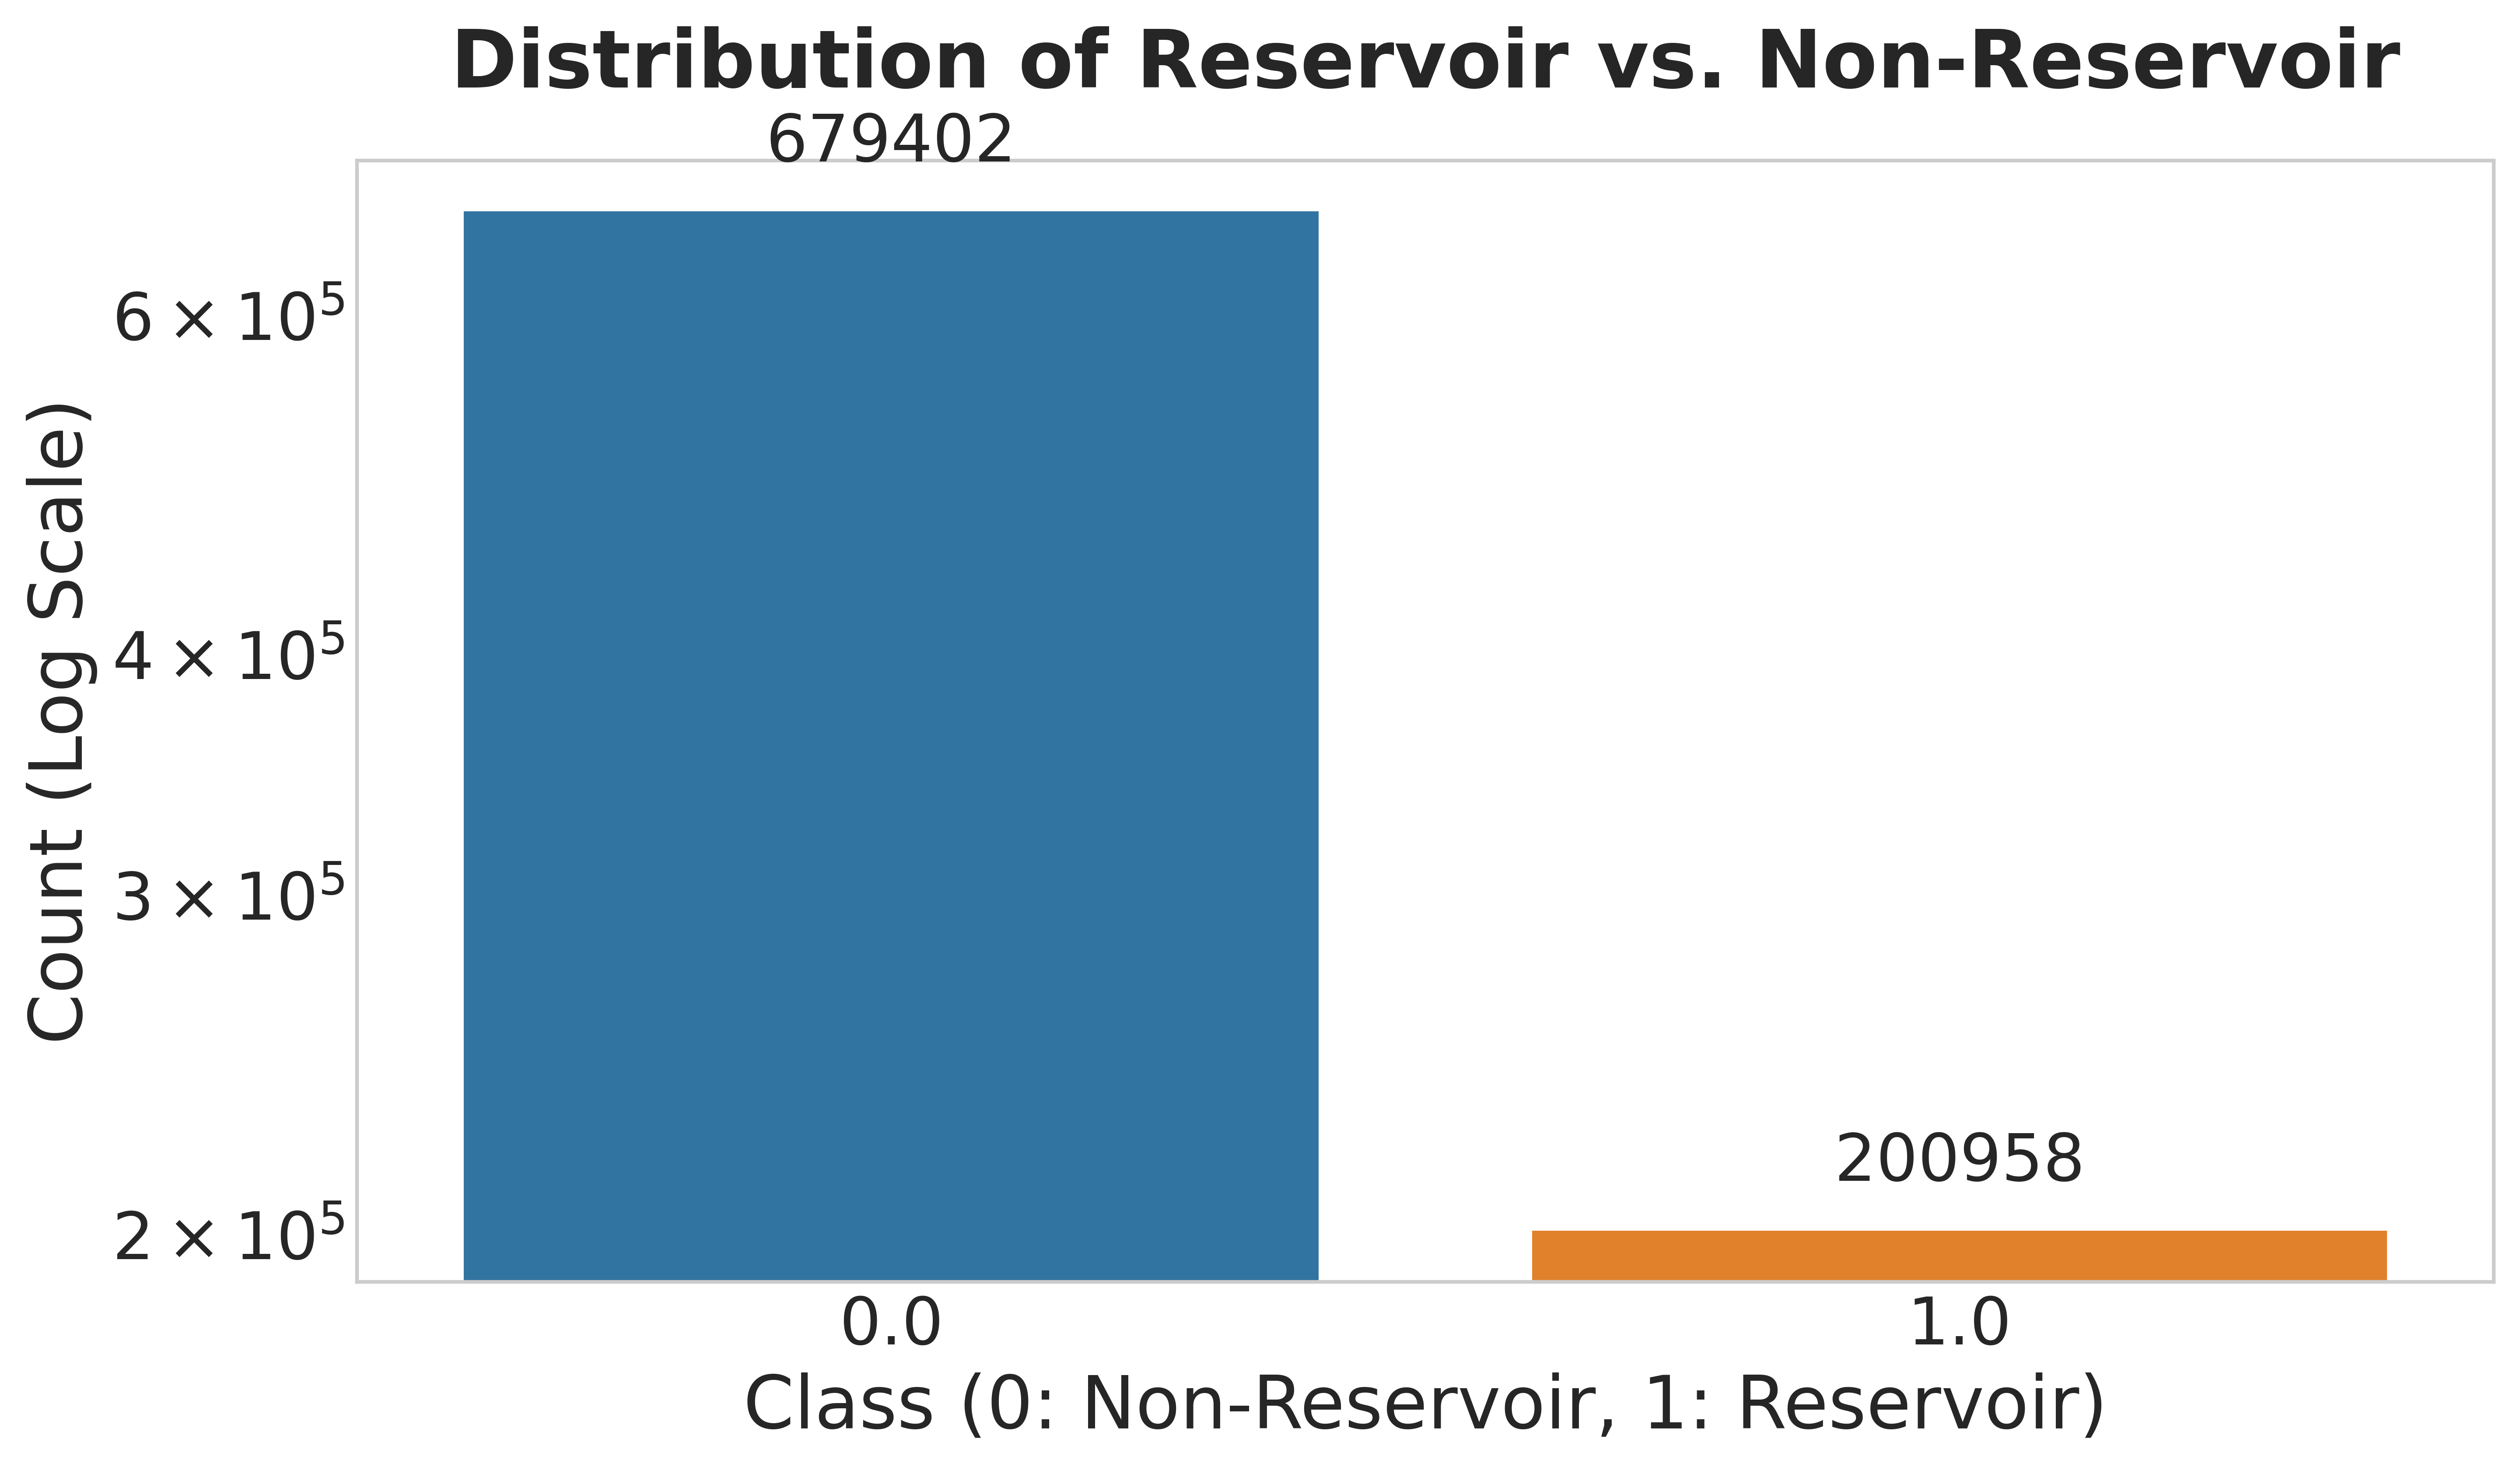

In [20]:
# Class distribution after lithology apping
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='target', data=df_clean, hue='target', legend=False)

plt.title('Distribution of Reservoir vs. Non-Reservoir', fontweight='bold', pad=20)
plt.xlabel('Class (0: Non-Reservoir, 1: Reservoir)')
plt.ylabel('Count (Log Scale)')
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'bottom', 
                    xytext = (0, 10), 
                    textcoords = 'offset points',
                    fontsize=18)
plt.tight_layout()

save_path = os.path.join(config.FIGURE_DIR_P1, "1_class_distribution.png")
plt.savefig(save_path, dpi=600)
print(f" Saved plot to: {save_path}")
plt.show()

In [21]:
# cleaned feature distributions (post-cleaning)
# the 1%-99% cropping here is only for visual clarity and does not indicate that the training data has been removed
cleaned_plot_features = [c for c in ['GR', 'RHOB', 'NPHI', 'DTC', 'PEF', 'RDEP', 'SP', 'CALI', 'DRHO'] if c in df_clean.columns]

if cleaned_plot_features:
    n_cols = 3
    n_rows = (len(cleaned_plot_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cleaned_plot_features):
        # Trim the range from 1% to 99% to display the distribution of the main body and avoid outliers from elongating the coordinate axes
        lower, upper = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
        plot_data = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        
        sns.histplot(data=plot_data, x=col, hue='target', 
                     element="step", stat="density", common_norm=False, 
                     palette={0: 'gray', 1: 'green'}, ax=axes[i], alpha=0.5)
        
        axes[i].set_title(f'Cleaned {col} Distribution', fontweight='bold', fontsize=16)
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Cleaned Feature Distributions by Class (1st-99th Percentile)', fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    save_path_cleaned = os.path.join(config.FIGURE_DIR_P1, "2_feature_distributions_cleaned.png")
    plt.savefig(save_path_cleaned, dpi=600)
    print(f" Saved cleaned distribution plot to: {save_path_cleaned}")
    plt.show()

 Saved cleaned distribution plot to: ../figures/data_plot/2_feature_distributions_cleaned.png


In [22]:
# feature correlation heatmap 
corr_features = [c for c in FULL_FEATURES if c in df_clean.columns] + ['target']

corr_matrix = df_clean[corr_features].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 12))

# cmap='coolwarm'，vmin=-1, vmax=1 
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            annot_kws={"size": 10}, cbar_kws={"shrink": .8})

plt.title('Spearman Correlation Heatmap (Features & Target)', fontsize=20, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

save_path_corr = os.path.join(config.FIGURE_DIR_P1, "3_correlation_heatmap.png")
plt.savefig(save_path_corr, dpi=600)
print(f" Saved correlation heatmap to: {save_path_corr}")
plt.show()

 Saved correlation heatmap to: ../figures/data_plot/3_correlation_heatmap.png


<span style="color:red; font-size:28px;">Tools Configuration and General Functions</span>

In [23]:
# import important libraries
import torch
import time
import gc
import omegaconf
import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback

# only use the median of inner_train_df and apply it to the validation set and test set to fix the error of loading the checkpoint of pytorch_tabular under PyTorch 2.6
if not hasattr(torch, '_original_load_saved'):
    torch._original_load_saved = torch.load  # store the original load
    
    def _patched_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return torch._original_load_saved(*args, **kwargs)
        
    torch.load = _patched_load
    print(" Successfully patched torch.load (Safe Mode)")
else:
    print(" torch.load was already patched. Skipping.")


from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
)
from pytorch_tabular import TabularModel
from pytorch_tabular.models import TabNetModelConfig, FTTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig

 Successfully patched torch.load (Safe Mode)


In [24]:
# import AutoInt
try:
    from pytorch_tabular.models import AutoIntConfig
    HAS_AUTOINT = True
    print(" AutoIntConfig available.")
except Exception as e:
    HAS_AUTOINT = False
    print(f" AutoIntConfig not available. Skipping AutoInt. Reason: {e}")

 AutoIntConfig available.


In [25]:
# hardware adaptation
if torch.cuda.is_available():
    ACCELERATOR = "gpu"   
    BATCH_SIZE = 1024
    print(" Accelerator:GPU (CUDA)")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    ACCELERATOR = "mps"    
    BATCH_SIZE = 512
    print(" Accelerator: MPS (Apple Silicon)")
else:
    ACCELERATOR = "cpu"
    BATCH_SIZE = 256
    print(" Accelerator: CPU")

# to define the basic setting
if config.DEBUG_MODE: 
    BATCH_SIZE = 256 

DL_CONFIG = {
    "batch_size": BATCH_SIZE, 
    "max_epochs": config.MAX_EPOCHS,           
    "early_stopping_patience": config.PATIENCE, 
    "learning_rate": 1e-3, 
    "num_workers": 0, 
    "accelerator": ACCELERATOR, 
    "devices": 1
}

 Accelerator:GPU (CUDA)


In [26]:
# to define the general functions need to use in order to better know which part need to imporve if something goes wrong
def apply_log_transform(df_in, feature_list, keywords, verbose=False):
    # Apply the Log1p transformation to correct the extremely right-skewed nature of resistivity and other characteristics
    df = df_in.copy()
    log_cols = [c for c in feature_list if any(k in c for k in keywords)]
    if verbose and log_cols: 
        print(f"   [Log Transform] Applied to: {log_cols}")
    for c in log_cols:
        if c in df.columns:
            x = df[c].astype("float32")
            x = np.clip(x, 1e-6, None) # to avoid <=0 lead to Log error occurred
            df[c] = np.log1p(x)
    return df

def optimize_threshold(y_true, y_prob):
    # search for the optimal F1 threshold on the validation set
    y_true = np.asarray(y_true).astype(int)
    if np.unique(y_true).size < 2: return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for thresh in np.arange(0.1, 0.91, 0.01):
        score = f1_score(y_true, (y_prob >= thresh).astype(int), zero_division=0)
        if score > best_f1: 
            best_f1, best_t = score, thresh
    return best_t, best_f1

def extract_probabilities(pred_df):
    candidates = ["1_probability", "target_1_probability", "class_1_probability", "prediction_probability", "probability"]
    for c in candidates:
        if c in pred_df.columns:
            probs = pred_df[c].values.astype(float)
            if np.nanmin(probs) < -0.01 or np.nanmax(probs) > 1.01:
                probs = 1 / (1 + np.exp(-probs))
            return probs
            
    prob_cols = [c for c in pred_df.columns if c.endswith("_probability")]
    not_zero = [c for c in prob_cols if not (c.startswith("0_") or "class_0" in c or "0_probability" in c)]
    prefer = [c for c in not_zero if "1_" in c or "target_1" in c or "class_1" in c]
    prob_col = prefer[0] if prefer else (not_zero[0] if not_zero else prob_cols[-1])
    probs = pred_df[prob_col].values.astype(float)
    
    if np.nanmin(probs) < -0.01 or np.nanmax(probs) > 1.01: 
        probs = 1 / (1 + np.exp(-probs))
    return probs

def calculate_comprehensive_metrics(y_true, y_pred, y_prob, time_taken, model_name):
    y_true = y_true.astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0) 
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # ROC-AUC
    try: roc_auc = roc_auc_score(y_true, y_prob)
    except: roc_auc = 0.5 
    
    # PR-AUC 
    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_prob)
    pr_auc_val = auc(recall_pts, precision_pts)

    # Specificity 
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    return {
        "Model": model_name,
        "Time (s)": round(time_taken, 2),
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "Specificity (%)": round(spec * 100, 2),
        "ROC-AUC (%)": round(roc_auc * 100, 2),
        "PR-AUC (%)": round(pr_auc_val * 100, 2)
    }

print(" Phase 2 Setup Complete. All Safety Systems Active.")

# define model architectures
def get_model_config(model_name):
    # return the corresponding PyTorch Tabular configuration based on the model name
    common_params = {"task": "classification", "learning_rate": DL_CONFIG["learning_rate"]}
    
    if model_name == "TabNet":
        return TabNetModelConfig(**common_params, n_d=16, n_a=16, n_steps=3, gamma=1.3)
    elif model_name == "FTTransformer":
        return FTTransformerConfig(**common_params, num_heads=4, num_attn_blocks=2, ff_dropout=0.1)
    elif model_name == "AutoInt":
        if not HAS_AUTOINT: raise ImportError("AutoInt not available.")
        return AutoIntConfig(**common_params, num_heads=4, num_attn_blocks=2)
    else:
        raise ValueError(f"Unknown model: {model_name}")

print(" Model Architectures Defined.")

 Phase 2 Setup Complete. All Safety Systems Active.
 Model Architectures Defined.


<span style="color:red; font-size:28px;">Model Training</span>

In [27]:
# the recorded histories that need to record for plots and files
class LossHistoryTracker(Callback):
    def __init__(self):
        self.history = []

    def on_train_epoch_end(self, trainer, pl_module):
        # at the end of each epoch to save the current loss
        epoch_metrics = {}
        for k, v in trainer.callback_metrics.items():
            epoch_metrics[k] = v.item() if isinstance(v, torch.Tensor) else v
        self.history.append(epoch_metrics)

# nested CV (core and full Features) training loop
feature_sets_to_test = {"Core": CORE_FEATURES, "Full": FULL_FEATURES}
active_models = ['FTTransformer'] if config.DEBUG_MODE else (['TabNet', 'AutoInt', 'FTTransformer'] if HAS_AUTOINT else ['TabNet', 'FTTransformer'])

all_fold_metrics = []
oof_predictions = {f: {m: {'y_true': [], 'y_prob': [], 'y_pred': []} for m in active_models} for f in feature_sets_to_test}
training_histories = {} 
outer_gkf = GroupKFold(n_splits=5)

print(f" Starting Training. Target Headers: Model, Time (s), Accuracy (%), etc.")

for f_set_name, current_features in feature_sets_to_test.items():
    print(f"\n Feature Set: {f_set_name}")
    for model_name in active_models:
        print(f"   Model: {model_name}")
        for fold, (tr_idx, te_idx) in enumerate(outer_gkf.split(df_clean, df_clean['target'], groups=df_clean['WELL'].values)):
            print(f"      Fold {fold+1}/5...", end=" ")
            
            # Split
            o_tr, o_te = df_clean.iloc[tr_idx].reset_index(drop=True), df_clean.iloc[te_idx].reset_index(drop=True)
            inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42+fold)
            idx_tr, idx_vl = next(inner.split(o_tr, groups=o_tr['WELL'].values))
            i_tr, i_vl = o_tr.iloc[idx_tr].reset_index(drop=True), o_tr.iloc[idx_vl].reset_index(drop=True)

            # Log Transform and Fill Median 
            res_kw = ['RDEP', 'RMED', 'RSHA', 'RXO']
            i_tr = apply_log_transform(i_tr, current_features, res_kw)
            i_vl = apply_log_transform(i_vl, current_features, res_kw)
            o_te = apply_log_transform(o_te, current_features, res_kw)
            
            for col in current_features:
                med = i_tr[col].median()
                i_tr[col] = i_tr[col].fillna(med)
                i_vl[col] = i_vl[col].fillna(med)
                o_te[col] = o_te[col].fillna(med)
            
           # Model Train
            tracker = LossHistoryTracker()
            tab_model = TabularModel(
                data_config=DataConfig(
                    target=["target"], 
                    continuous_cols=current_features, 
                    normalize_continuous_features=True
                ),
                model_config=get_model_config(model_name),
                optimizer_config=OptimizerConfig(),
                trainer_config=TrainerConfig(
                    batch_size=DL_CONFIG["batch_size"], 
                    max_epochs=DL_CONFIG["max_epochs"], 
                    early_stopping="valid_loss",
                    early_stopping_patience=DL_CONFIG["early_stopping_patience"],
                    accelerator=DL_CONFIG["accelerator"], 
                    devices=1, 
                    progress_bar="none", 
                    checkpoints_path=config.MODEL_DIR,
                    checkpoints_name=f"{model_name}_{f_set_name}_fold{fold}"
                ),
                verbose=False 
            )
            
            st = time.time()
            tab_model.fit(train=i_tr, validation=i_vl, callbacks=[tracker])
            dur = time.time() - st
            
            # Predict & Metrics
            v_probs = extract_probabilities(tab_model.predict(i_vl))
            thresh, _ = optimize_threshold(i_vl['target'].values, v_probs)
            t_probs = extract_probabilities(tab_model.predict(o_te))
            t_preds = (t_probs >= thresh).astype(int)
            
            m = calculate_comprehensive_metrics(o_te['target'].values, t_preds, t_probs, dur, model_name)
            m['FeatureSet'] = f_set_name
            all_fold_metrics.append(m)
            
            # OOF
            oof_predictions[f_set_name][model_name]['y_true'].extend(o_te['target'].values)
            oof_predictions[f_set_name][model_name]['y_prob'].extend(t_probs)
            oof_predictions[f_set_name][model_name]['y_pred'].extend(t_preds)
            if fold == 0: training_histories[f"{model_name}_{f_set_name}"] = pd.DataFrame(tracker.history)

            del tab_model; gc.collect(); torch.cuda.empty_cache()
            print(f"Done (F1: {m['F1-Score (%)']:.1f}%)")

raw_results = pd.DataFrame(all_fold_metrics)

summary_df = raw_results.groupby(['Model', 'FeatureSet']).mean(numeric_only=True).reset_index()

final_cols = [
    'Model', 'FeatureSet', 'Time (s)', 'Accuracy (%)', 'Precision (%)', 
    'Recall (%)', 'F1-Score (%)', 'Specificity (%)', 'ROC-AUC (%)', 'PR-AUC (%)'
]

final_table = summary_df[final_cols].round(2)
excel_path = os.path.join(config.REPORT_DIR, "model_final_summary.xlsx")
final_table.to_excel(excel_path, index=False)

print(f"\n Professional Summary Saved to: {excel_path}")
print(final_table)

 Starting Training. Target Headers: Model, Time (s), Accuracy (%), etc.

 Feature Set: Core
   Model: TabNet
      Fold 1/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 5060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.1 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.1 K    Trainable params
0         Non

Done (F1: 58.2%)
      Fold 2/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.1 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.1 K    Trainable params
0         Non-trainable params
21.1 K    Total params
0.084     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 74.2%)
      Fold 3/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.1 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.1 K    Trainable params
0         Non-trainable params
21.1 K    Total params
0.084     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 78.2%)
      Fold 4/5... 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.1 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.1 K    Trainable params
0         Non-trainable params
21.1 K    Total params
0.084     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/ccs_env/lib/pyth

Done (F1: 73.7%)
      Fold 5/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.1 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.1 K    Trainable params
0         Non-trainable params
21.1 K    Total params
0.084     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 68.4%)
   Model: AutoInt
      Fold 1/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 170    | train
2 | _head            | LinearHead       | 322    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 56.2%)
      Fold 2/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 170    | train
2 | _head            | LinearHead       | 322    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 72.8%)
      Fold 3/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 170    | train
2 | _head            | LinearHead       | 322    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 75.7%)
      Fold 4/5... 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 170    | train
2 | _head            | LinearHead       | 322    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/ccs_env/lib/pyth

Done (F1: 74.5%)
      Fold 5/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 170    | train
2 | _head            | LinearHead       | 322    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 68.4%)
   Model: FTTransformer
      Fold 1/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 330    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.1 K    Trainable params
0         Non-trainable params
58.1 K    Total params
0.232     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in 

Done (F1: 57.6%)
      Fold 2/5... 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 330    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.1 K    Trainable params
0         Non-trainable params
58.1 K    Total params
0.232     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
/home

Done (F1: 74.2%)
      Fold 3/5... 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 330    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.1 K    Trainable params
0         Non-trainable params
58.1 K    Total params
0.232     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
/home

Done (F1: 76.4%)
      Fold 4/5... 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 330    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.1 K    Trainable params
0         Non-trainable params
58.1 K    Total params
0.232     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
/home

Done (F1: 74.9%)
      Fold 5/5... 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 330    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.1 K    Trainable params
0         Non-trainable params
58.1 K    Total params
0.232     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
/home

Done (F1: 72.4%)

 Feature Set: Full
   Model: TabNet
      Fold 1/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.6 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.6 K    Trainable params
0         Non-trainable params
21.6 K    Total params
0.086     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 57.5%)
      Fold 2/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.6 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.6 K    Trainable params
0         Non-trainable params
21.6 K    Total params
0.086     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 72.8%)
      Fold 3/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.6 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.6 K    Trainable params
0         Non-trainable params
21.6 K    Total params
0.086     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 77.6%)
      Fold 4/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.6 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.6 K    Trainable params
0         Non-trainable params
21.6 K    Total params
0.086     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 76.4%)
      Fold 5/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _embedding_layer | Identity         | 0      | train
1 | _backbone        | TabNetBackbone   | 21.6 K | train
2 | _head            | Identity         | 0      | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
21.6 K    Trainable params
0         Non-trainable params
21.6 K    Total params
0.086     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 76.1%)
   Model: AutoInt
      Fold 1/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 306    | train
2 | _head            | LinearHead       | 578    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.4 K    Trainable params
0         Non-trainable params
10.4 K    Total params
0.042     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 61.5%)
      Fold 2/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 306    | train
2 | _head            | LinearHead       | 578    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.4 K    Trainable params
0         Non-trainable params
10.4 K    Total params
0.042     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 74.9%)
      Fold 3/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 306    | train
2 | _head            | LinearHead       | 578    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.4 K    Trainable params
0         Non-trainable params
10.4 K    Total params
0.042     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 78.8%)
      Fold 4/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 306    | train
2 | _head            | LinearHead       | 578    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.4 K    Trainable params
0         Non-trainable params
10.4 K    Total params
0.042     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 74.0%)
      Fold 5/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | _backbone        | AutoIntBackbone  | 9.5 K  | train
1 | _embedding_layer | Embedding2dLayer | 306    | train
2 | _head            | LinearHead       | 578    | train
3 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
10.4 K    Trainable params
0         Non-trainable params
10.4 K    Total params
0.042     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/hardy/ccs_project/c

Done (F1: 73.1%)
   Model: FTTransformer
      Fold 1/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 594    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.4 K    Trainable params
0         Non-trainable params
58.4 K    Total params
0.233     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in 

Done (F1: 61.7%)
      Fold 2/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 594    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.4 K    Trainable params
0         Non-trainable params
58.4 K    Total params
0.233     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in 

Done (F1: 75.0%)
      Fold 3/5... 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 594    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.4 K    Trainable params
0         Non-trainable params
58.4 K    Total params
0.233     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
/home

Done (F1: 75.7%)
      Fold 4/5... 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 594    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.4 K    Trainable params
0         Non-trainable params
58.4 K    Total params
0.233     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
/home

Done (F1: 76.6%)
      Fold 5/5... 

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/saved_models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 594    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.4 K    Trainable params
0         Non-trainable params
58.4 K    Total params
0.233     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in 

Done (F1: 75.3%)

 Professional Summary Saved to: ../reports/model_final_summary.xlsx
           Model FeatureSet  Time (s)  Accuracy (%)  Precision (%)  \
0        AutoInt       Core    252.24         85.96          72.82   
1        AutoInt       Full    249.81         88.03          76.84   
2  FTTransformer       Core    276.92         86.49          71.94   
3  FTTransformer       Full    307.33         87.50          73.14   
4         TabNet       Core    708.91         87.23          76.56   
5         TabNet       Full    716.21         86.72          71.37   

   Recall (%)  F1-Score (%)  Specificity (%)  ROC-AUC (%)  PR-AUC (%)  
0       70.36         69.53            90.37        90.85       80.90  
1       69.67         72.47            93.53        90.17       75.62  
2       73.01         71.10            90.27        91.05       81.33  
3       73.75         72.87            91.48        90.82       77.85  
4       68.08         70.53            92.71        90.62      

<span style="color:red; font-size:28px;">Visualizations</span>

In [43]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from matplotlib.ticker import MaxNLocator

os.makedirs(config.FIGURE_DIR_P2, exist_ok=True)

sns.set_palette("deep")

# traverse all the trained feature sets
for f_set_name in feature_sets_to_test.keys():
    print(f"  Generating Individual Plots for: [{f_set_name}] Features")
    
    current_oof = oof_predictions[f_set_name]

    # for each model under this feature set
    for model_name in active_models:
        print(f"   -> Drawing plots for {model_name}...")
        
        # extract the actual values and the predicted values
        y_t = current_oof[model_name]['y_true']
        y_p = current_oof[model_name]['y_pred']
        y_prob = current_oof[model_name]['y_prob']
        
        # Learning Curve
        history_key = f"{model_name}_{f_set_name}"
        if history_key in training_histories:
            history = training_histories[history_key]
            t_loss = next((c for c in history.columns if 'train_loss' in c), None)
            v_loss = next((c for c in history.columns if 'valid_loss' in c or 'val_loss' in c), None)
    
            if t_loss and v_loss:
                fig_lc, ax_lc = plt.subplots(figsize=(8, 5)) 
                epochs = range(len(history))
                tr_loss_vals = history[t_loss].values
                val_loss_vals = history[v_loss].values

                ax_lc.plot(epochs, tr_loss_vals, label='Train Loss', linestyle='--', color='#1f77b4', lw=2, zorder=3)
                ax_lc.plot(epochs, val_loss_vals, label='Validation Loss', linestyle='-', color='#d95f02', lw=2, zorder=3)
                
                best_epoch = np.argmin(val_loss_vals)
                best_val = val_loss_vals[best_epoch]
                ax_lc.axvline(x=best_epoch, color='gray', linestyle=':', lw=1.5, zorder=1)
                ax_lc.plot(best_epoch, best_val, marker='*', color='#d95f02', markersize=12, zorder=5)
                ax_lc.annotate(f'Best Val: {best_val:.4f}',
                               xy=(best_epoch, best_val), 
                               xytext=(0, -25), 
                               textcoords='offset points',
                               fontsize=10, fontweight='bold', color='#d95f02',
                               ha='center', va='top',
                               bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7),
                               arrowprops=dict(arrowstyle='->', color='#d95f02', lw=1.2, alpha=0.8))

                final_epoch = epochs[-1]
                final_train = tr_loss_vals[-1]
                final_val = val_loss_vals[-1]
                ax_lc.plot(final_epoch, final_train, marker='o', color='#1f77b4', markersize=6, zorder=4)
                ax_lc.annotate(f'{final_train:.4f}',
                               xy=(final_epoch, final_train), 
                               xytext=(8, 0), textcoords='offset points',
                               fontsize=10, fontweight='bold', color='#1f77b4', va='center')
                ax_lc.plot(final_epoch, final_val, marker='o', color='#d95f02', markersize=6, zorder=4)
                ax_lc.annotate(f'{final_val:.4f}',
                               xy=(final_epoch, final_val), 
                               xytext=(8, 0), textcoords='offset points',
                               fontsize=10, fontweight='bold', color='#d95f02', va='center')

                ax_lc.set_xlim(left=-1, right=final_epoch + (len(epochs) * 0.15))

                ax_lc.set_title(f'Learning Curve: {model_name} ({f_set_name})', fontweight='bold', fontsize=13, pad=10)
                ax_lc.set_xlabel('Epochs', fontsize=11, fontweight='bold')
                ax_lc.set_ylabel('Loss', fontsize=11, fontweight='bold')
                ax_lc.xaxis.set_major_locator(MaxNLocator(integer=True))
                ax_lc.spines['top'].set_visible(False)
                ax_lc.spines['right'].set_visible(False)
                ax_lc.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1))
                plt.tight_layout()
                plt.savefig(os.path.join(config.FIGURE_DIR_P2, f"4_learning_curve_{f_set_name}_{model_name}.png"), dpi=600, bbox_inches='tight')
                plt.close(fig_lc)

        if len(y_t) > 0:
            # Confusion Matrix 
            fig_cm, ax_cm = plt.subplots(figsize=(5, 4.5))
            cm = confusion_matrix(y_t, y_p, labels=[0, 1])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax_cm)
            ax_cm.set_title(f'Confusion Matrix: {model_name} ({f_set_name})', fontweight='bold', pad=10)
            ax_cm.set_xlabel('Predicted', fontweight='bold')
            ax_cm.set_ylabel('True', fontweight='bold')
            ax_cm.set_xticklabels(['Non-Res', 'Reservoir'])
            ax_cm.set_yticklabels(['Non-Res', 'Reservoir'], rotation=0)
            plt.tight_layout()
            plt.savefig(os.path.join(config.FIGURE_DIR_P2, f"5_confusion_matrix_{f_set_name}_{model_name}.png"), dpi=600, bbox_inches='tight')
            plt.close(fig_cm)


            # ROC Curve 
            fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
            ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, zorder=1)
            fpr, tpr, _ = roc_curve(y_t, y_prob)
            r_auc = auc(fpr, tpr)
            
            ax_roc.plot(fpr, tpr, label=f'AUC = {r_auc:.3f}', lw=2, color='#d95f02', zorder=3)
            ax_roc.set_title(f'ROC Curve: {model_name} ({f_set_name})', fontweight='bold', pad=10)
            ax_roc.set_xlabel('False Positive Rate', fontweight='bold')
            ax_roc.set_ylabel('True Positive Rate', fontweight='bold')
            
            ax_roc.spines['top'].set_visible(False)
            ax_roc.spines['right'].set_visible(False)
            ax_roc.legend(loc="best", fontsize=11, frameon=False)
            
            plt.tight_layout()
            plt.savefig(os.path.join(config.FIGURE_DIR_P2, f"6_roc_curve_{f_set_name}_{model_name}.png"), dpi=600, bbox_inches='tight')
            plt.close(fig_roc)

            # Precision-Recall Curve 
            fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
            prec, rec, _ = precision_recall_curve(y_t, y_prob)
            p_auc = auc(rec, prec)
            
            ax_pr.plot(rec, prec, label=f'PR-AUC = {p_auc:.3f}', lw=2, color='#1b9e77', zorder=3)
            ax_pr.set_title(f'Precision-Recall Curve: {model_name} ({f_set_name})', fontweight='bold', pad=10)
            ax_pr.set_xlabel('Recall (Sensitivity)', fontweight='bold')
            ax_pr.set_ylabel('Precision', fontweight='bold')
            
            ax_pr.spines['top'].set_visible(False)
            ax_pr.spines['right'].set_visible(False)
            ax_pr.legend(loc="best", fontsize=11, frameon=False)
            
            plt.tight_layout()
            plt.savefig(os.path.join(config.FIGURE_DIR_P2, f"7_pr_curve_{f_set_name}_{model_name}.png"), dpi=600, bbox_inches='tight')
            plt.close(fig_pr)

print("\n All individual plots successfully generated and saved in Academic Style!")

  Generating Individual Plots for: [Core] Features
   -> Drawing plots for TabNet...
   -> Drawing plots for AutoInt...
   -> Drawing plots for FTTransformer...
  Generating Individual Plots for: [Full] Features
   -> Drawing plots for TabNet...
   -> Drawing plots for AutoInt...
   -> Drawing plots for FTTransformer...

 All individual plots successfully generated and saved in Academic Style!


<span style="color:red; font-size:28px;">Cross-Dataset Generalization</span>

In [29]:
# enforce the declaration of paths to prevent NameErrors caused by memory loss within the Notebook
REPORT_DIR = "../reports"
if not os.path.exists(REPORT_DIR): os.makedirs(REPORT_DIR)

print("  PHASE 3: CROSS-DATASET GENERALIZATION (TARIM)")

try:
    _ = final_excel_df  
    print(" Found 'final_excel_df' in memory.")
except NameError:
    print(" 'final_excel_df' not in memory. Loading from saved Excel report...")
    excel_path = os.path.join(REPORT_DIR, "model_final_summary.xlsx")
    if os.path.exists(excel_path):
        final_excel_df = pd.read_excel(excel_path)
    else:
        raise FileNotFoundError(f" Cannot find {excel_path}. You MUST run Phase 2 training first!")

# select the championship model
core_results = final_excel_df[final_excel_df['FeatureSet'] == 'Core']
champion_row = core_results.sort_values('F1-Score (%)', ascending=False).iloc[0]

CHAMP_MODEL_NAME = champion_row['Model']
champ_features = CORE_FEATURES  # ['GR', 'RHOB', 'NPHI', 'PEF', 'DTC']
print(f" Champion Model Selected: {CHAMP_MODEL_NAME} (Trained on Core-5)")

# prepare the final training data
final_splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=config.RANDOM_SEED)
idx_train, idx_val = next(final_splitter.split(df_clean, groups=df_clean['WELL'].values))

force_train = df_clean.iloc[idx_train].reset_index(drop=True)
force_val = df_clean.iloc[idx_val].reset_index(drop=True)

res_keywords = getattr(config, 'RESISTIVITY_KEYWORDS', ['RDEP', 'RMED', 'RSHA', 'RXO', 'RMIC'])
force_train = apply_log_transform(force_train, champ_features, res_keywords, verbose=True)
force_val   = apply_log_transform(force_val, champ_features, res_keywords)

  PHASE 3: CROSS-DATASET GENERALIZATION (TARIM)
 'final_excel_df' not in memory. Loading from saved Excel report...
 Champion Model Selected: FTTransformer (Trained on Core-5)


In [31]:
# calculate and save the median of the FORCE training set, which will be used later to fill in Tarim
force_medians = {}
for col in champ_features:
    med = force_train[col].median()
    force_medians[col] = med
    force_train[col] = force_train[col].fillna(med)
    force_val[col] = force_val[col].fillna(med)

# configure and train the champion model
data_config = DataConfig(
    target=["target"], continuous_cols=champ_features, categorical_cols=[], 
    normalize_continuous_features=True, num_workers=0
)

trainer_config = TrainerConfig(
    batch_size=DL_CONFIG["batch_size"], max_epochs=config.MAX_EPOCHS, 
    early_stopping="valid_loss", early_stopping_patience=config.PATIENCE, 
    accelerator=DL_CONFIG["accelerator"], devices=1, progress_bar="none",
    checkpoints_path="saved_models/final_champion"
)

champion_model = TabularModel(
    data_config=data_config, model_config=get_model_config(CHAMP_MODEL_NAME),
    optimizer_config=OptimizerConfig(), trainer_config=trainer_config, verbose=False
)

print(f"\n Training Final {CHAMP_MODEL_NAME} on FORCE 2020...")
start_time = time.time()
tracker = LossHistoryTracker()
champion_model.fit(train=force_train, validation=force_val, callbacks=[tracker])
print(f" Training Complete in {time.time() - start_time:.1f} seconds.")
champion_model.save_model("saved_models/my_true_champion")
print(" Calibrating optimal decision threshold on FORCE validation set...")
final_val_probs = extract_probabilities(champion_model.predict(force_val))
CHAMP_THRESH, best_val_f1 = optimize_threshold(force_val['target'].values, final_val_probs)
print(f" Optimized Threshold locked at: {CHAMP_THRESH:.2f} (Val F1: {best_val_f1:.4f})")

Seed set to 42



 Training Final FTTransformer on FORCE 2020...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/hardy/ccs_project/ccs_env/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/hardy/ccs_project/notebook/saved_models/final_champion exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                  | Params | Mode 
-------------------------------------------------------------------
0 | _backbone        | FTTransformerBackbone | 57.7 K | train
1 | _embedding_layer | Embedding2dLayer      | 330    | train
2 | _head            | LinearHead            | 66     | train
3 | loss             | CrossEntropyLoss      | 0      | train
-------------------------------------------------------------------
58.1 K    Trainable params
0         Non-trainable params
58.1 K    Total params
0.232     Total estimated model params size (MB)
50        Modules in train mode
0         Mo

 Training Complete in 361.3 seconds.
 Calibrating optimal decision threshold on FORCE validation set...
 Optimized Threshold locked at: 0.56 (Val F1: 0.7553)



Generating Threshold-F1 Sensitivity Curve (on Validation Set)...


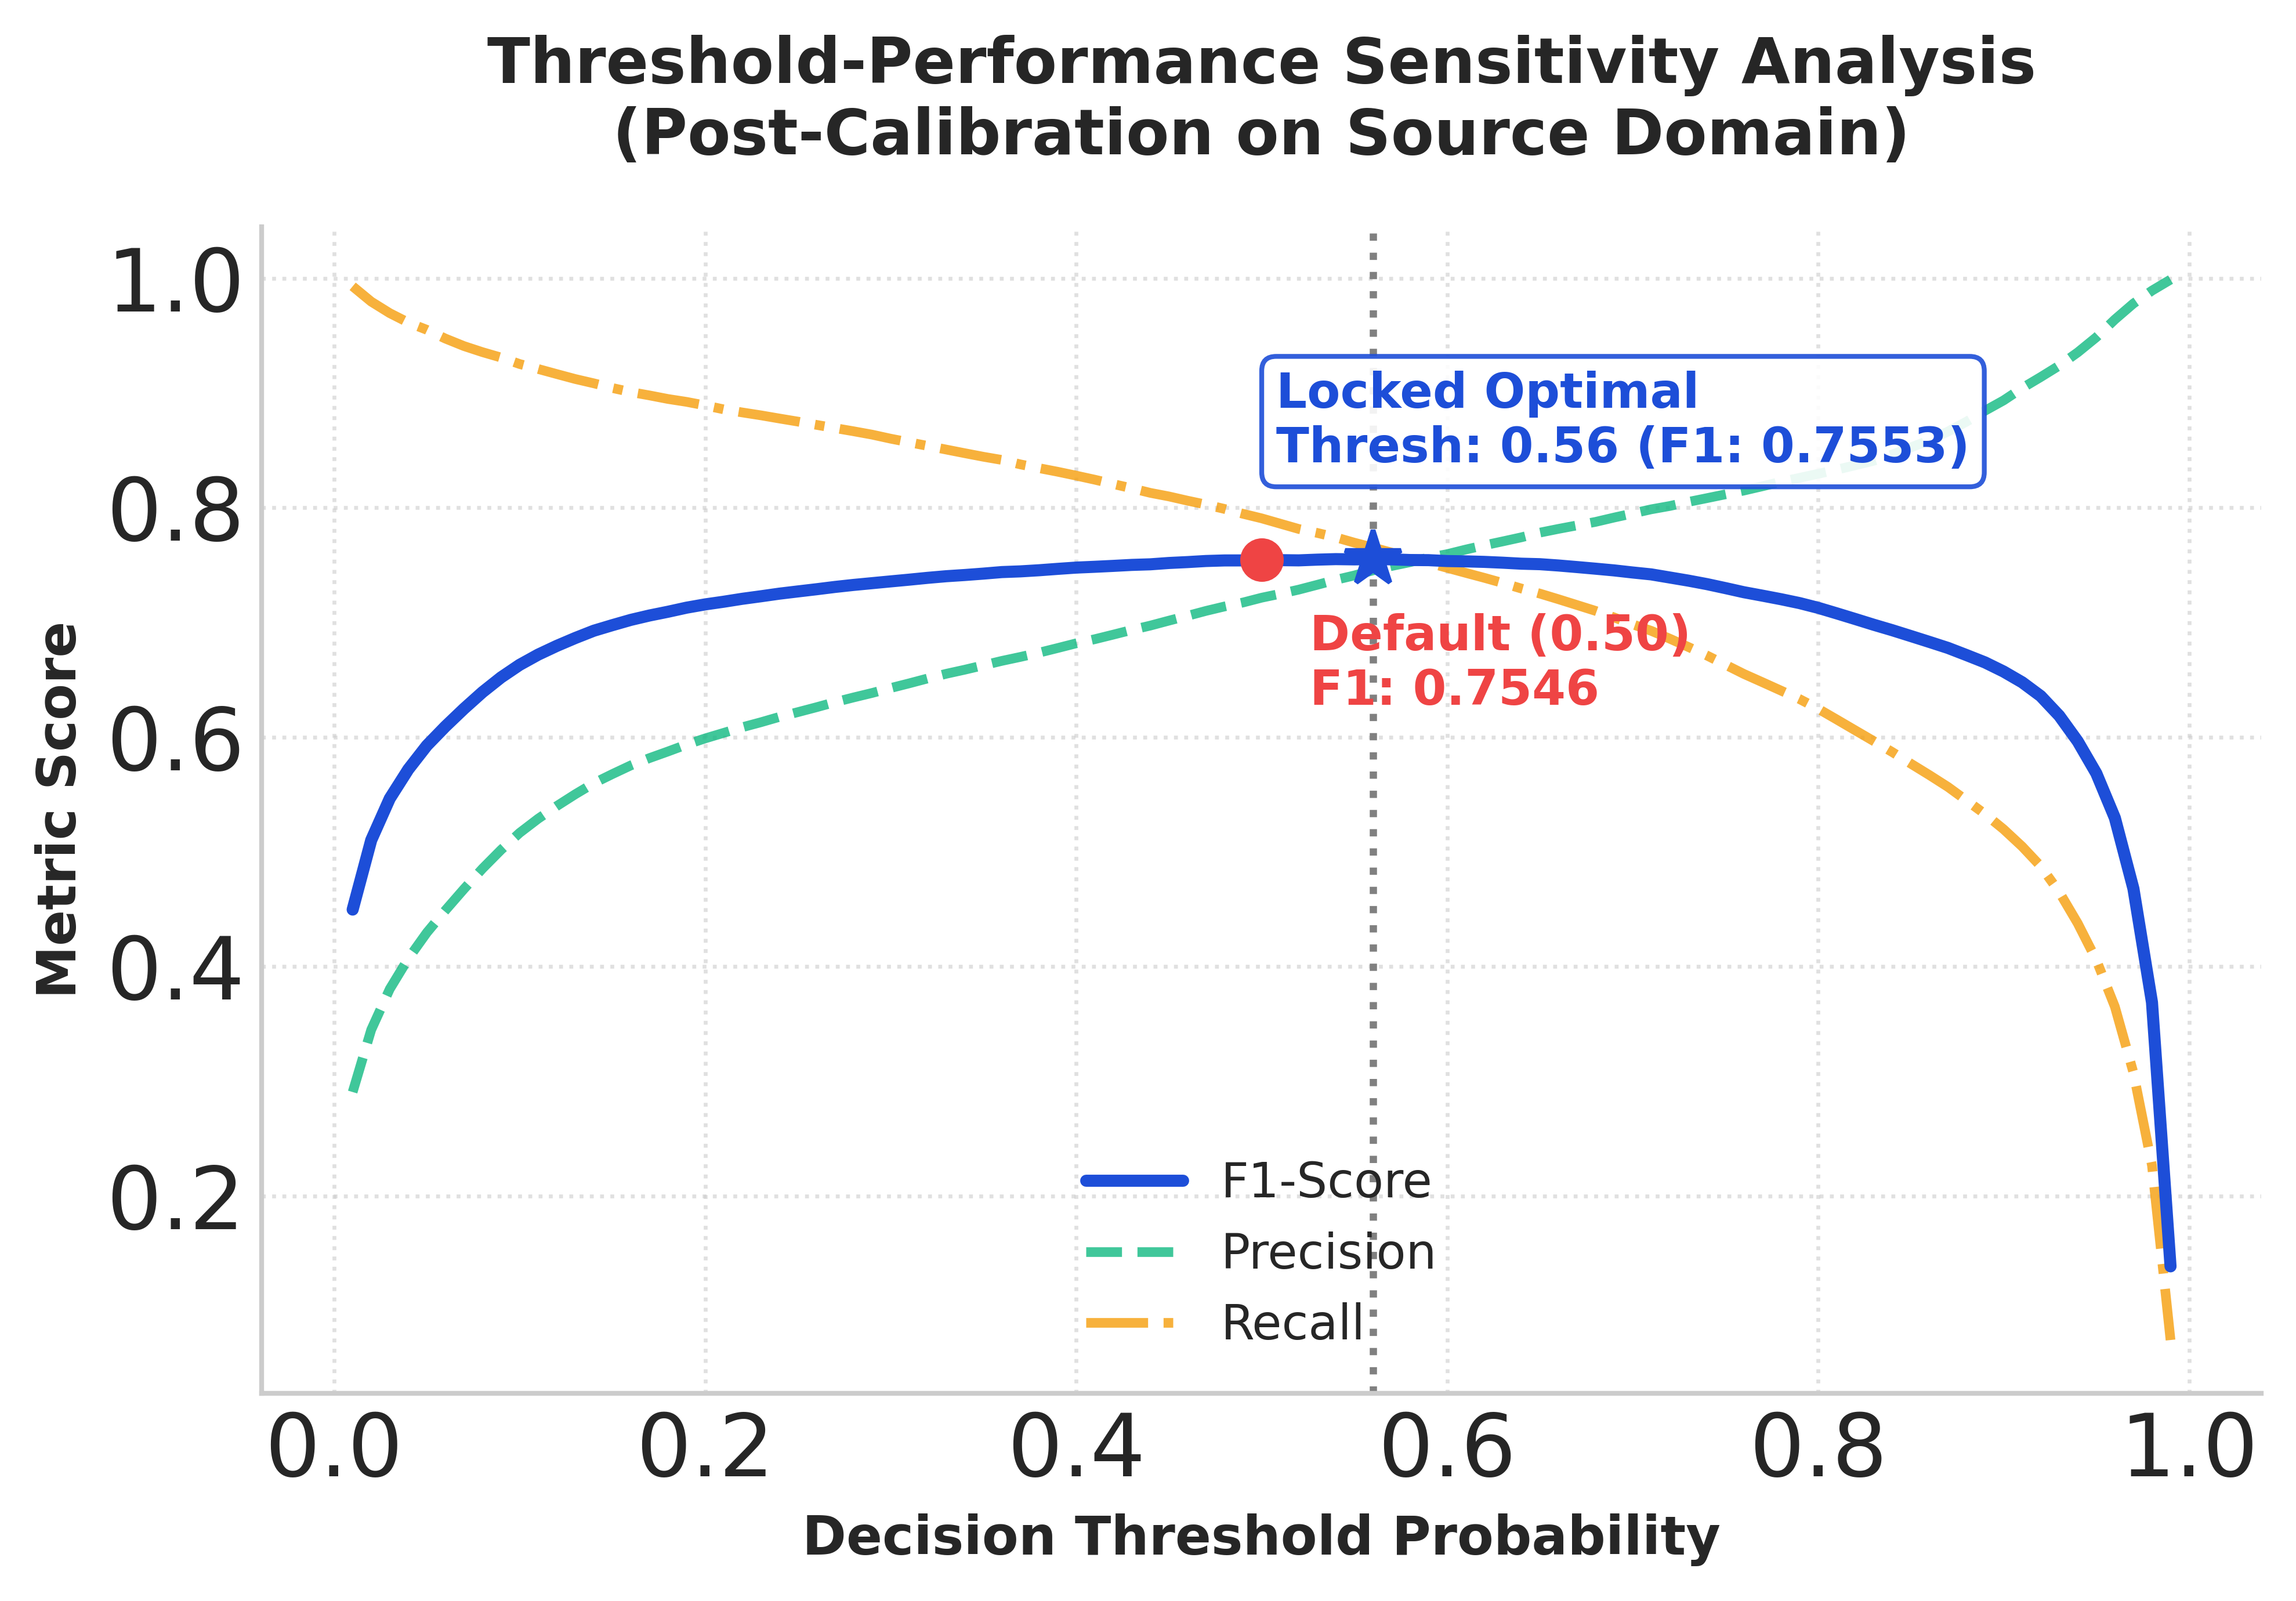

 Saved Threshold Calibration plot to: ../figures/model_plot/8_X_threshold_calibration_source.png


In [32]:
# Threshold Calibration Curve 

print("\nGenerating Threshold-F1 Sensitivity Curve (on Validation Set)...")

y_val_true = force_val['target'].values

thresholds = np.arange(0.01, 1.00, 0.01)

f1_scores, precisions, recalls = [], [], []

for t in thresholds:
    preds_t = (final_val_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val_true, preds_t, zero_division=0))
    precisions.append(precision_score(y_val_true, preds_t, zero_division=0))
    recalls.append(recall_score(y_val_true, preds_t, zero_division=0))

fig_t, ax_t = plt.subplots(figsize=(7, 5))

ax_t.plot(thresholds, f1_scores, label='F1-Score', color='#1d4ed8', lw=2.5, zorder=4)

ax_t.plot(thresholds, precisions, label='Precision', color='#10b981', lw=2, linestyle='--', alpha=0.8, zorder=3)

ax_t.plot(thresholds, recalls, label='Recall', color='#f59e0b', lw=2, linestyle='-.', alpha=0.8, zorder=3)


# Highlight the optimal threshold point

ax_t.axvline(x=CHAMP_THRESH, color='gray', linestyle=':', lw=1.5, zorder=1)

ax_t.plot(CHAMP_THRESH, best_val_f1, marker='*', color='#1d4ed8', markersize=12, zorder=5)
ax_t.annotate(f'Locked Optimal\nThresh: {CHAMP_THRESH:.2f} (F1: {best_val_f1:.4f})',

xy=(CHAMP_THRESH, best_val_f1),

xytext=(-20, 20),

textcoords='offset points',

fontsize=10, fontweight='bold', color='#1d4ed8',

bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1d4ed8", alpha=0.9), zorder=6)

# Compare with the default threshold of 0.5

idx_05 = np.argmin(np.abs(thresholds - 0.5))

f1_05 = f1_scores[idx_05]

ax_t.plot(0.5, f1_05, marker='o', color='#ef4444', markersize=8, zorder=5)

ax_t.annotate(f'Default (0.50)\nF1: {f1_05:.4f}',

xy=(0.5, f1_05),

xytext=(10, -30),

textcoords='offset points',

fontsize=10, fontweight='bold', color='#ef4444', zorder=6)

ax_t.set_title('Threshold-Performance Sensitivity Analysis\n(Post-Calibration on Source Domain)', fontweight='bold', fontsize=13, pad=15)

ax_t.set_xlabel('Decision Threshold Probability', fontsize=11, fontweight='bold')

ax_t.set_ylabel('Metric Score', fontsize=11, fontweight='bold')

ax_t.spines['top'].set_visible(False)

ax_t.spines['right'].set_visible(False)

ax_t.grid(True, linestyle=':', alpha=0.6, zorder=0)

ax_t.legend(loc='lower center', fontsize=10, frameon=False)

plt.tight_layout()

os.makedirs(config.FIGURE_DIR_P2, exist_ok=True)

CALIB_PLOT_PATH = os.path.join(config.FIGURE_DIR_P2, "8_X_threshold_calibration_source.png")

plt.savefig(CALIB_PLOT_PATH, dpi=600, bbox_inches='tight')

plt.show()

plt.close(fig_t)

print(f" Saved Threshold Calibration plot to: {CALIB_PLOT_PATH}")

<span style="color:red; font-size:28px;">Prepare another dataset</span>

In [33]:
tarim_path = os.path.join(config.DATA_DIR, config.TEST_FILE)
print(f" Loading external dataset from: {tarim_path}")
df_tarim = pd.read_excel(tarim_path)

tarim_rename_map = {
    'PE': 'PEF',
    'GR': 'GR',
    'AC': 'DTC',
    'CNL': 'NPHI',
    'DEN': 'RHOB'
}
df_tarim = df_tarim.rename(columns=tarim_rename_map)

target_col = None
for col in df_tarim.columns:
    if col not in tarim_rename_map.values():
        target_col = col
        break

if target_col is not None:
    print(f" Found Label Column: '{target_col}'. Mapping 1->1 (Res), 2->0 (Non-Res)")
    df_tarim['target'] = df_tarim[target_col].map({1: 0, 2: 1})
else:
    raise ValueError(" Could not find the 6th label column in Tarim dataset!")

tarim_clean = df_tarim.dropna(subset=['target']).copy()
tarim_clean['target'] = tarim_clean['target'].astype(int)

if 'NPHI' in tarim_clean.columns and tarim_clean['NPHI'].mean() > 5:
    print(" Auto-calibrating NPHI scale: Converting percentage (%) to decimal...")
    tarim_clean['NPHI'] = tarim_clean['NPHI'] / 100.0

for col in champ_features:
    # If the entire column is missing, simply create it using the median value from the source domain
    if col not in tarim_clean.columns:
        print(f" Missing {col} entirely in Tarim, filling with FORCE median ({force_medians[col]:.2f}).")
        tarim_clean[col] = force_medians[col]
    else:
        # If the column exists, check for any scattered missing values (NaN). If there are any, fill them with the median of the source domain
        missing_count = tarim_clean[col].isnull().sum()
        if missing_count > 0:
            print(f" Found {missing_count} missing values in Tarim '{col}', filling with FORCE median.")
            tarim_clean[col] = tarim_clean[col].fillna(force_medians[col])

print(f" Tarim Data Preprocessed. Shape: {tarim_clean.shape}")

 Loading external dataset from: ../data/test.xlsx
 Found Label Column: 'Unnamed: 5'. Mapping 1->1 (Res), 2->0 (Non-Res)
 Auto-calibrating NPHI scale: Converting percentage (%) to decimal...
 Tarim Data Preprocessed. Shape: (1600, 7)


<span style="color:red; font-size:28px;">Cross-dataset generalization evaluation and plotting</span>

 Predicting on Tarim dataset using champion model...

 Using strict Baseline Threshold from Phase 2: 0.56

  BLIND TEST RESULTS ON TARIM DATASET (STRICT)
  Accuracy (%)        : 88.88
  Precision (%)       : 93.75
  Recall (%)          : 82.25
  F1-Score (%)        : 87.62
  Specificity (%)     : 94.96
  ROC-AUC (%)         : 96.21
  PR-AUC (%)          : 96.31

Generating Final Learning Curve...


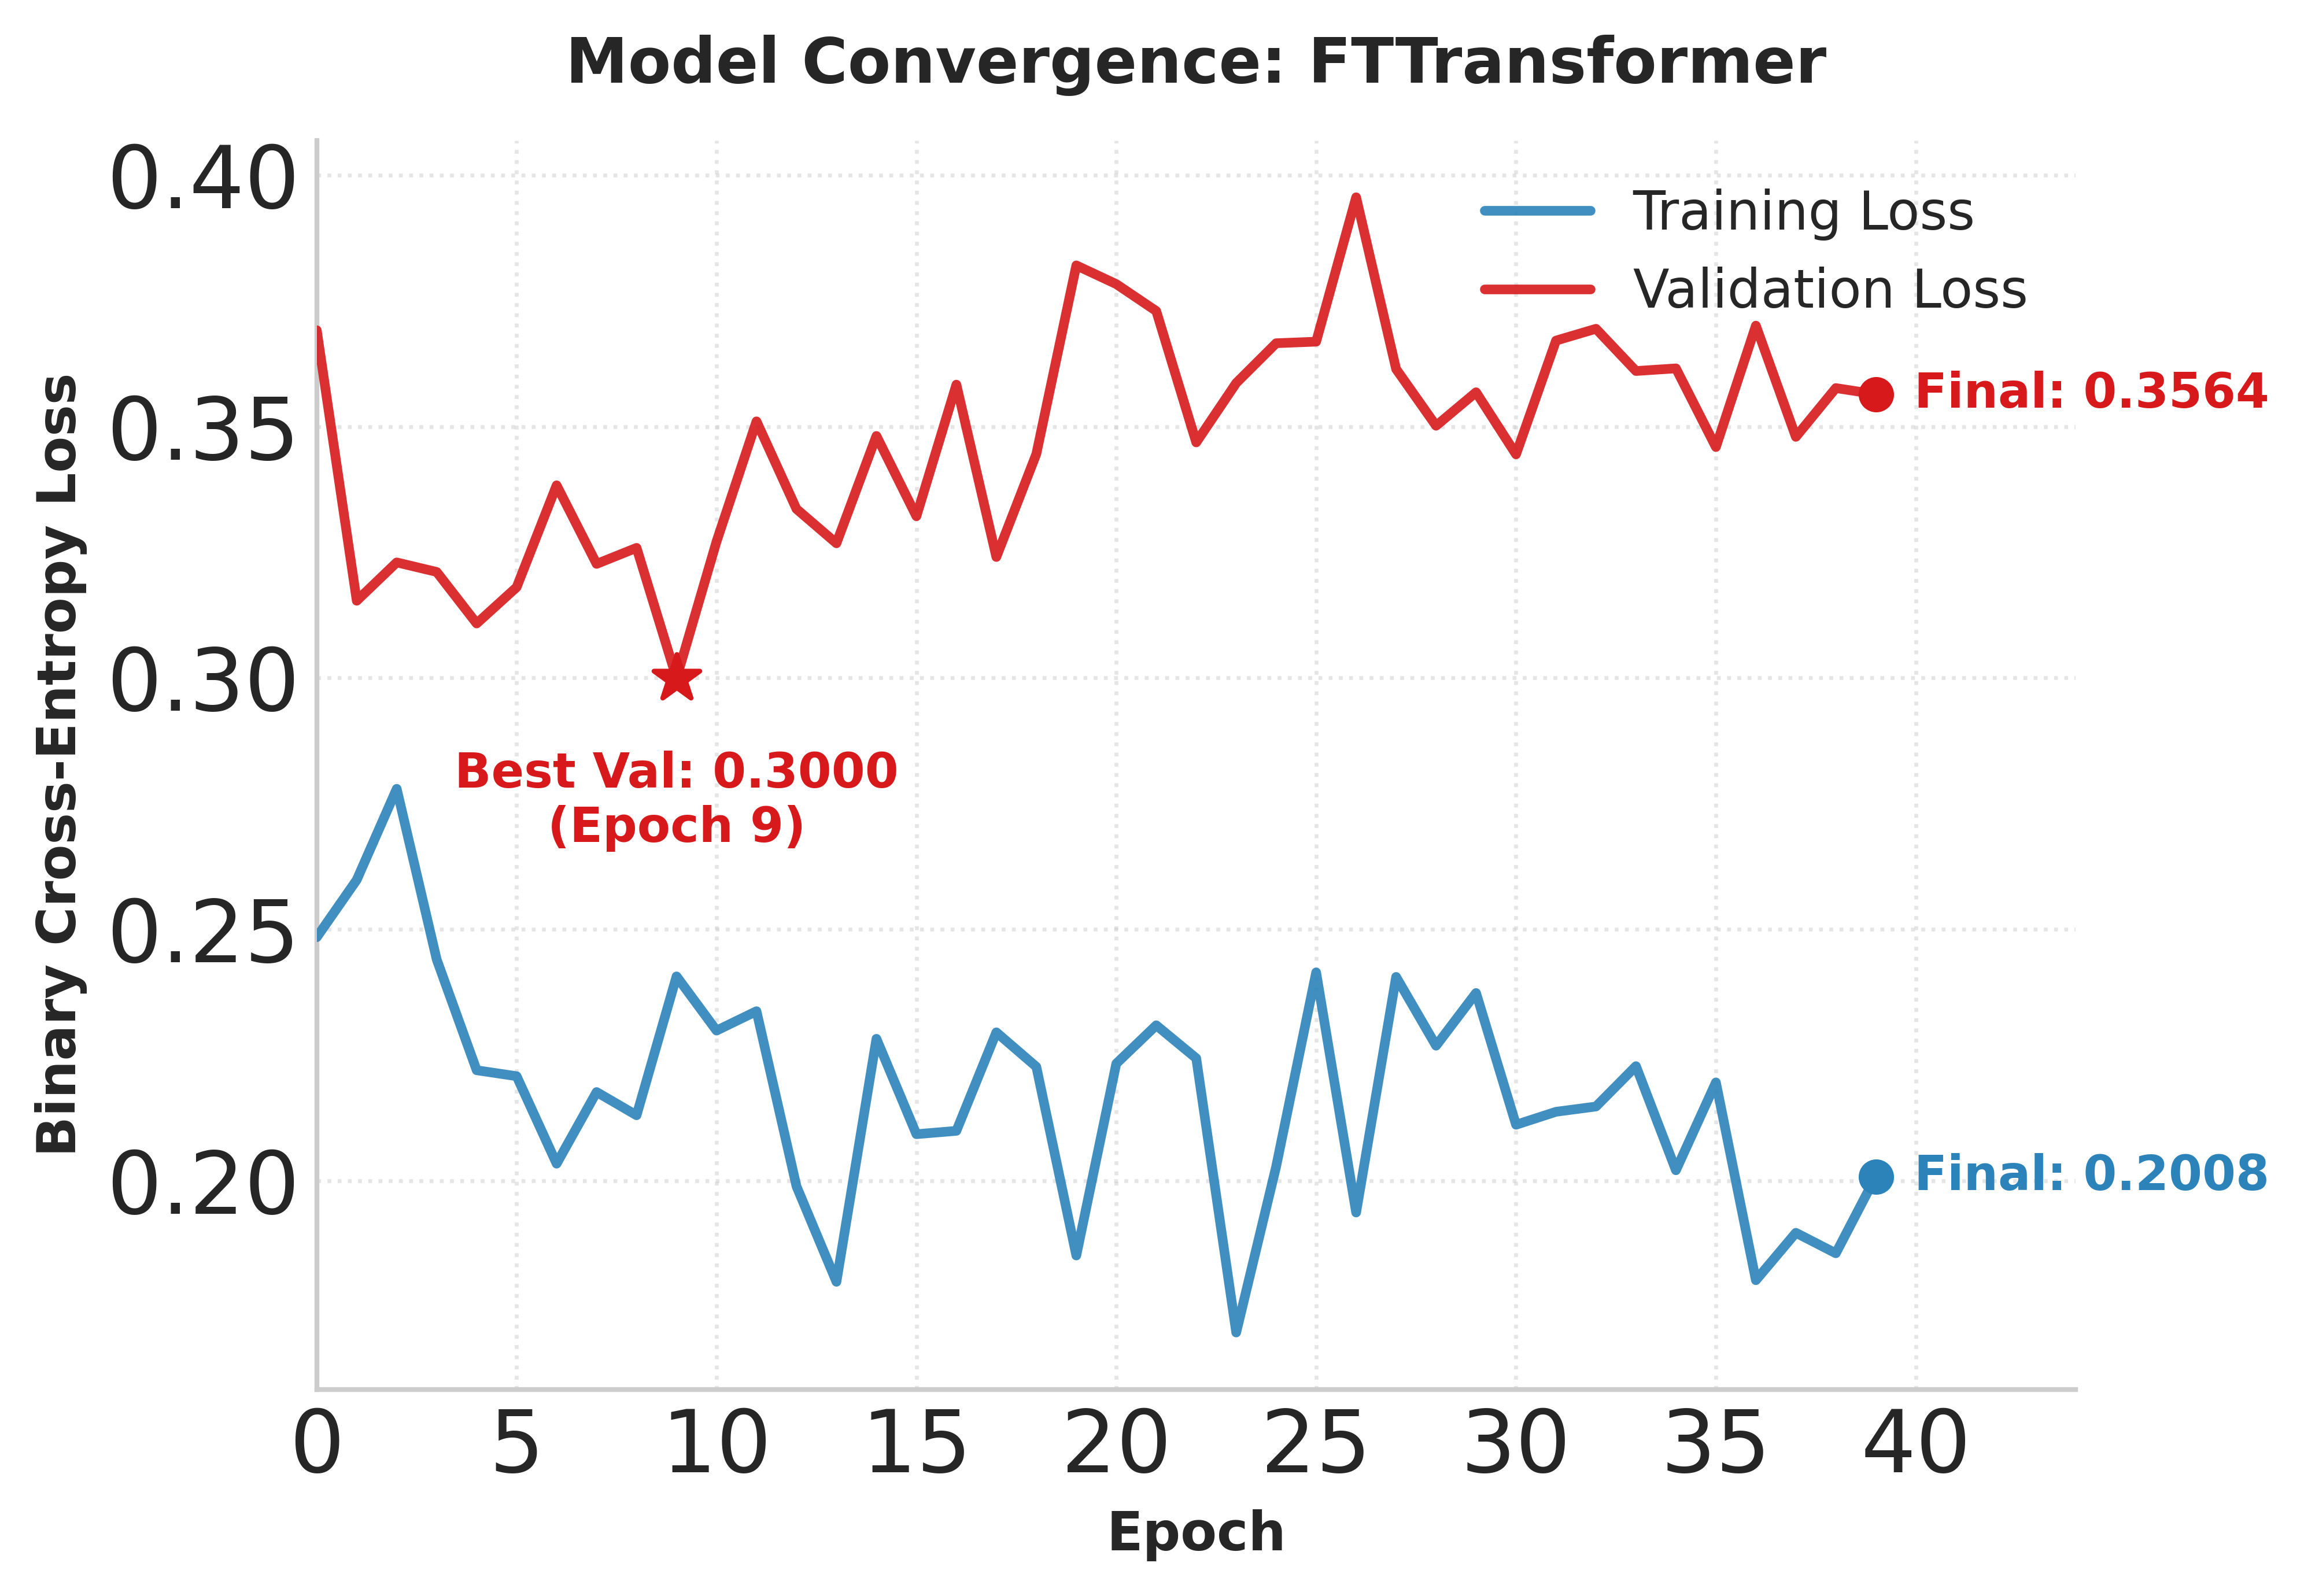


Generating Confusion Matrix...
Generating ROC Curve...
Generating Precision-Recall Curve...
  DISCUSSION: WHAT IF WE CALIBRATE LOCALLY?
If we calibrate the threshold for Tarim specifically:
 -> Optimal Local Threshold shifts from 0.56 to 0.26
 -> Recall    changes from 82.25% to 96.87%
 -> Precision changes from 93.75% to 84.51%
 -> F1-Score  changes from 87.62% to 90.27%
************************************************************

Saving Tarim blind test metrics to Excel...
 Excel report successfully saved to: ../reports/tarim_blind_test_results.xlsx


In [42]:
TARIM_FIGURE_DIR = "../figures/tarim_generalization"
if not os.path.exists(TARIM_FIGURE_DIR): os.makedirs(TARIM_FIGURE_DIR)
REPORT_DIR = "../reports"
if not os.path.exists(REPORT_DIR): os.makedirs(REPORT_DIR)

res_keywords = getattr(config, 'RESISTIVITY_KEYWORDS', ['RDEP', 'RMED', 'RSHA', 'RXO', 'RMIC'])
tarim_clean = apply_log_transform(tarim_clean, champ_features, res_keywords)
print(" Predicting on Tarim dataset using champion model...")
infer_start = time.time()
tarim_pred_df = champion_model.predict(tarim_clean)
infer_time = time.time() - infer_start
tarim_probs = extract_probabilities(tarim_pred_df)
y_tarim_true = tarim_clean['target'].values

# if AUC is less than 0.5, it indicates that the predicted probabilities are completely reversed from the actual labels
fpr_temp, tpr_temp, _ = roc_curve(y_tarim_true, tarim_probs)
temp_auc = auc(fpr_temp, tpr_temp)
if temp_auc < 0.45:
    print(f" DANGER: Tarim AUC is {temp_auc:.3f} (< 0.5). Target labels 1 and 2 might be mapped incorrectly!")
    print(" Please check Cell 11 mapping dict. The model is predicting the exact opposite of reality.")


print(f"\n Using strict Baseline Threshold from Phase 2: {CHAMP_THRESH:.2f}")
tarim_optimal_thresh = CHAMP_THRESH  

# perform the final binary classification based on the baseline threshold
tarim_preds = (tarim_probs >= tarim_optimal_thresh).astype(int)

tarim_metrics = calculate_comprehensive_metrics(y_tarim_true, tarim_preds, tarim_probs, infer_time, f"{CHAMP_MODEL_NAME} (Tarim)")

print("\n" + "="*45)
print("  BLIND TEST RESULTS ON TARIM DATASET (STRICT)")
print("="*45)
for k, v in tarim_metrics.items():
    if k not in ['Model', 'Time (s)', 'Confusion Matrix']:
        print(f"  {k:<20}: {v}")
print("="*45)


sns.set_palette("deep")

# Final Learning Curve 
print("\nGenerating Final Learning Curve...")

if 'tracker' in globals() and len(tracker.history) > 0:
    history_df = pd.DataFrame(tracker.history)
    t_loss = next((c for c in history_df.columns if 'train_loss' in c), None)
    v_loss = next((c for c in history_df.columns if 'valid_loss' in c or 'val_loss' in c), None)

    if t_loss and v_loss:
        best_epoch = history_df[v_loss].idxmin()
        best_val_loss = history_df[v_loss].iloc[best_epoch]
        
        final_epoch = len(history_df) - 1
        final_train_loss = history_df[t_loss].iloc[-1]
        final_val_loss = history_df[v_loss].iloc[-1]
        
        fig0, ax0 = plt.subplots(figsize=(7, 5))
        epochs = range(len(history_df))
        tr_loss_vals = history_df[t_loss].values
        val_loss_vals = history_df[v_loss].values
        ax0.plot(epochs, tr_loss_vals, label='Training Loss', linestyle='-', color='#2b83ba', lw=2, alpha=0.9, zorder=3)
        ax0.plot(epochs, val_loss_vals, label='Validation Loss', linestyle='-', color='#d7191c', lw=2, alpha=0.9, zorder=3)
        ax0.scatter(best_epoch, best_val_loss, color='#d7191c', s=100, marker='*', zorder=5)
        ax0.annotate(f'Best Val: {best_val_loss:.4f}\n(Epoch {best_epoch})',
                     xy=(best_epoch, best_val_loss), 
                     xytext=(0, -15), textcoords='offset points',
                     fontsize=10, fontweight='bold', color='#d7191c',
                     ha='center', va='top')
        ax0.scatter(final_epoch, final_train_loss, color='#2b83ba', s=40, marker='o', zorder=5)
        ax0.annotate(f'Final: {final_train_loss:.4f}',
                     xy=(final_epoch, final_train_loss), 
                     xytext=(8, 0), textcoords='offset points',
                     fontsize=10, fontweight='bold', color='#2b83ba',
                     ha='left', va='center')
        ax0.scatter(final_epoch, final_val_loss, color='#d7191c', s=40, marker='o', zorder=5)
        ax0.annotate(f'Final: {final_val_loss:.4f}',
                     xy=(final_epoch, final_val_loss), 
                     xytext=(8, 0), textcoords='offset points',
                     fontsize=10, fontweight='bold', color='#d7191c',
                     ha='left', va='center')
        ax0.set_title(f'Model Convergence: {CHAMP_MODEL_NAME}', fontweight='bold', fontsize=13, pad=12)
        ax0.set_xlabel('Epoch', fontsize=11, fontweight='bold')
        ax0.set_ylabel('Binary Cross-Entropy Loss', fontsize=11, fontweight='bold')
        ax0.set_xlim(0, final_epoch + max(5, int(final_epoch * 0.15)))
        ax0.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax0.grid(True, linestyle=':', alpha=0.5, zorder=0)
        ax0.spines['top'].set_visible(False)
        ax0.spines['right'].set_visible(False)
        ax0.legend(frameon=False, fontsize=11, loc='upper right')
        plt.tight_layout()
        plt.savefig(os.path.join(TARIM_FIGURE_DIR, "8_0_final_learning_curve.png"), dpi=600, bbox_inches='tight')
        plt.show()
        plt.close(fig0)


#  Tarim Confusion Matrix 
print("\nGenerating Confusion Matrix...")
fig1, ax1 = plt.subplots(figsize=(5, 4.5))
cm = confusion_matrix(y_tarim_true, tarim_preds, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, 
            annot_kws={"size": 16, "weight": "bold"}, ax=ax1)
ax1.set_title(f'Tarim Confusion Matrix\n(Strict Threshold = {tarim_optimal_thresh:.2f})', fontweight='bold', fontsize=13, pad=10)
ax1.set_xlabel('Predicted Class', fontsize=11, fontweight='bold')
ax1.set_ylabel('True Class', fontsize=11, fontweight='bold')
ax1.set_xticklabels(['Non-Res', 'Reservoir'])
ax1.set_yticklabels(['Non-Res', 'Reservoir'], rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(TARIM_FIGURE_DIR, "8_1_tarim_confusion_matrix.png"), dpi=600, bbox_inches='tight')
plt.close(fig1)


# Tarim ROC Curve 
print("Generating ROC Curve...")
fig2, ax2 = plt.subplots(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_tarim_true, tarim_probs)
r_auc = auc(fpr, tpr)

ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, zorder=1)
ax2.plot(fpr, tpr, color='#d95f02', label=f'Tarim Test (AUC={r_auc:.3f})', lw=2, zorder=3)

ax2.set_title('Tarim ROC Curve (Blind Test)', fontweight='bold', fontsize=13, pad=10)
ax2.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc="lower right", fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(TARIM_FIGURE_DIR, "8_2_tarim_roc_curve.png"), dpi=600, bbox_inches='tight')
plt.close(fig2)


# Tarim PR Curve 
print("Generating Precision-Recall Curve...")
fig3, ax3 = plt.subplots(figsize=(6, 5))
prec, rec, _ = precision_recall_curve(y_tarim_true, tarim_probs)
p_auc = auc(rec, prec)

ax3.plot(rec, prec, color='#1b9e77', label=f'Tarim Test (AUC={p_auc:.3f})', lw=2, zorder=3)

ax3.set_title('Tarim Precision-Recall Curve (Blind Test)', fontweight='bold', fontsize=13, pad=10)
ax3.set_xlabel('Recall (Sensitivity)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=11, fontweight='bold')

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.legend(loc="lower left", fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(TARIM_FIGURE_DIR, "8_3_tarim_pr_curve.png"), dpi=600, bbox_inches='tight')
plt.close(fig3)


# Local Calibration
print("  DISCUSSION: WHAT IF WE CALIBRATE LOCALLY?")
print("="*60)

# suppose we obtain a few labels in the Tarim region, and then re-search for the optimal threshold
best_local_thresh, best_local_f1 = optimize_threshold(y_tarim_true, tarim_probs)
calibrated_preds = (tarim_probs >= best_local_thresh).astype(int)

# dynamic calculation of several core indicators after calibration
calibrated_recall = recall_score(y_tarim_true, calibrated_preds) * 100
calibrated_prec = precision_score(y_tarim_true, calibrated_preds, zero_division=0) * 100

# extract baseline indicators for comparison
base_recall = tarim_metrics['Recall (%)']
base_prec = tarim_metrics['Precision (%)']
base_f1 = tarim_metrics['F1-Score (%)']

print(f"If we calibrate the threshold for Tarim specifically:")
print(f" -> Optimal Local Threshold shifts from {CHAMP_THRESH:.2f} to {best_local_thresh:.2f}")
print(f" -> Recall    changes from {base_recall:.2f}% to {calibrated_recall:.2f}%")
print(f" -> Precision changes from {base_prec:.2f}% to {calibrated_prec:.2f}%")
print(f" -> F1-Score  changes from {base_f1:.2f}% to {best_local_f1*100:.2f}%")
print("*"*60)

print("\nSaving Tarim blind test metrics to Excel...")
tarim_df = pd.DataFrame([tarim_metrics])
tarim_excel_path = os.path.join(REPORT_DIR, "tarim_blind_test_results.xlsx")
tarim_df.to_excel(tarim_excel_path, index=False)
print(f" Excel report successfully saved to: {tarim_excel_path}")

<span style="color:red; font-size:28px;">SHAP Plot</span>

In [35]:
import shap

warnings.filterwarnings("ignore", message=".*The default of 'normalize' will be set to False.*")
shap.initjs()

print("="*50)
print(" PHASE 4: MODEL EXPLAINABILITY ON TARIM")
print("="*50)

# Extract the background set
print("Summarizing background data using K-Means clustering (50 centroids)...")
background_data = force_train[champ_features]
X_background_summary = shap.sample(background_data, 50, random_state=config.RANDOM_SEED)

# Extract the explanation set
n_explain = 200 if getattr(config, 'DEBUG_MODE', True) else 500
n_explain = min(n_explain, len(tarim_clean)) # Prevent the sample size from exceeding the total amount of data in the Tarim region
print(f"Sampling {n_explain} validation points from TARIM dataset for global explanation...")
X_explain = tarim_clean[champ_features].sample(n=n_explain, random_state=config.RANDOM_SEED)

# Define the prediction function
def predict_fn(x_numpy):
    df_temp = pd.DataFrame(x_numpy, columns=champ_features)
    for col in champ_features:
        # Use "get" to prevent Tarim from failing due to the absence of certain columns.
        df_temp[col] = df_temp[col].fillna(force_medians.get(col, 0))
    preds = champion_model.predict(df_temp)
    probs = extract_probabilities(preds)
    return probs

print("Initializing SHAP Explainer...")
explainer = shap.Explainer(predict_fn, X_background_summary)

print(f"Calculating SHAP values for {n_explain} Tarim points...")
start_time = time.time()
shap_values = explainer(X_explain)
print(f" SHAP calculation completed in {time.time() - start_time:.1f} seconds.")

 PHASE 4: MODEL EXPLAINABILITY ON TARIM
Summarizing background data using K-Means clustering (50 centroids)...
Sampling 500 validation points from TARIM dataset for global explanation...
Initializing SHAP Explainer...
Calculating SHAP values for 500 Tarim points...


ExactExplainer explainer: 501it [00:23, 14.18it/s]                                                                      

 SHAP calculation completed in 23.3 seconds.


Generating 1/6: SHAP Summary Plot...
Generating 2/6: SHAP Bar Plot (Global Feature Importance)...
Generating 3/6: SHAP Dependence Plot...
Generating 4/6: SHAP Waterfall Plot...
Generating 5/6: SHAP Force Plot...
Generating 6/6: Reservoir Probability Histogram (Tarim)...

 Phase 4 Complete! All 6 explainability plots are safely saved.


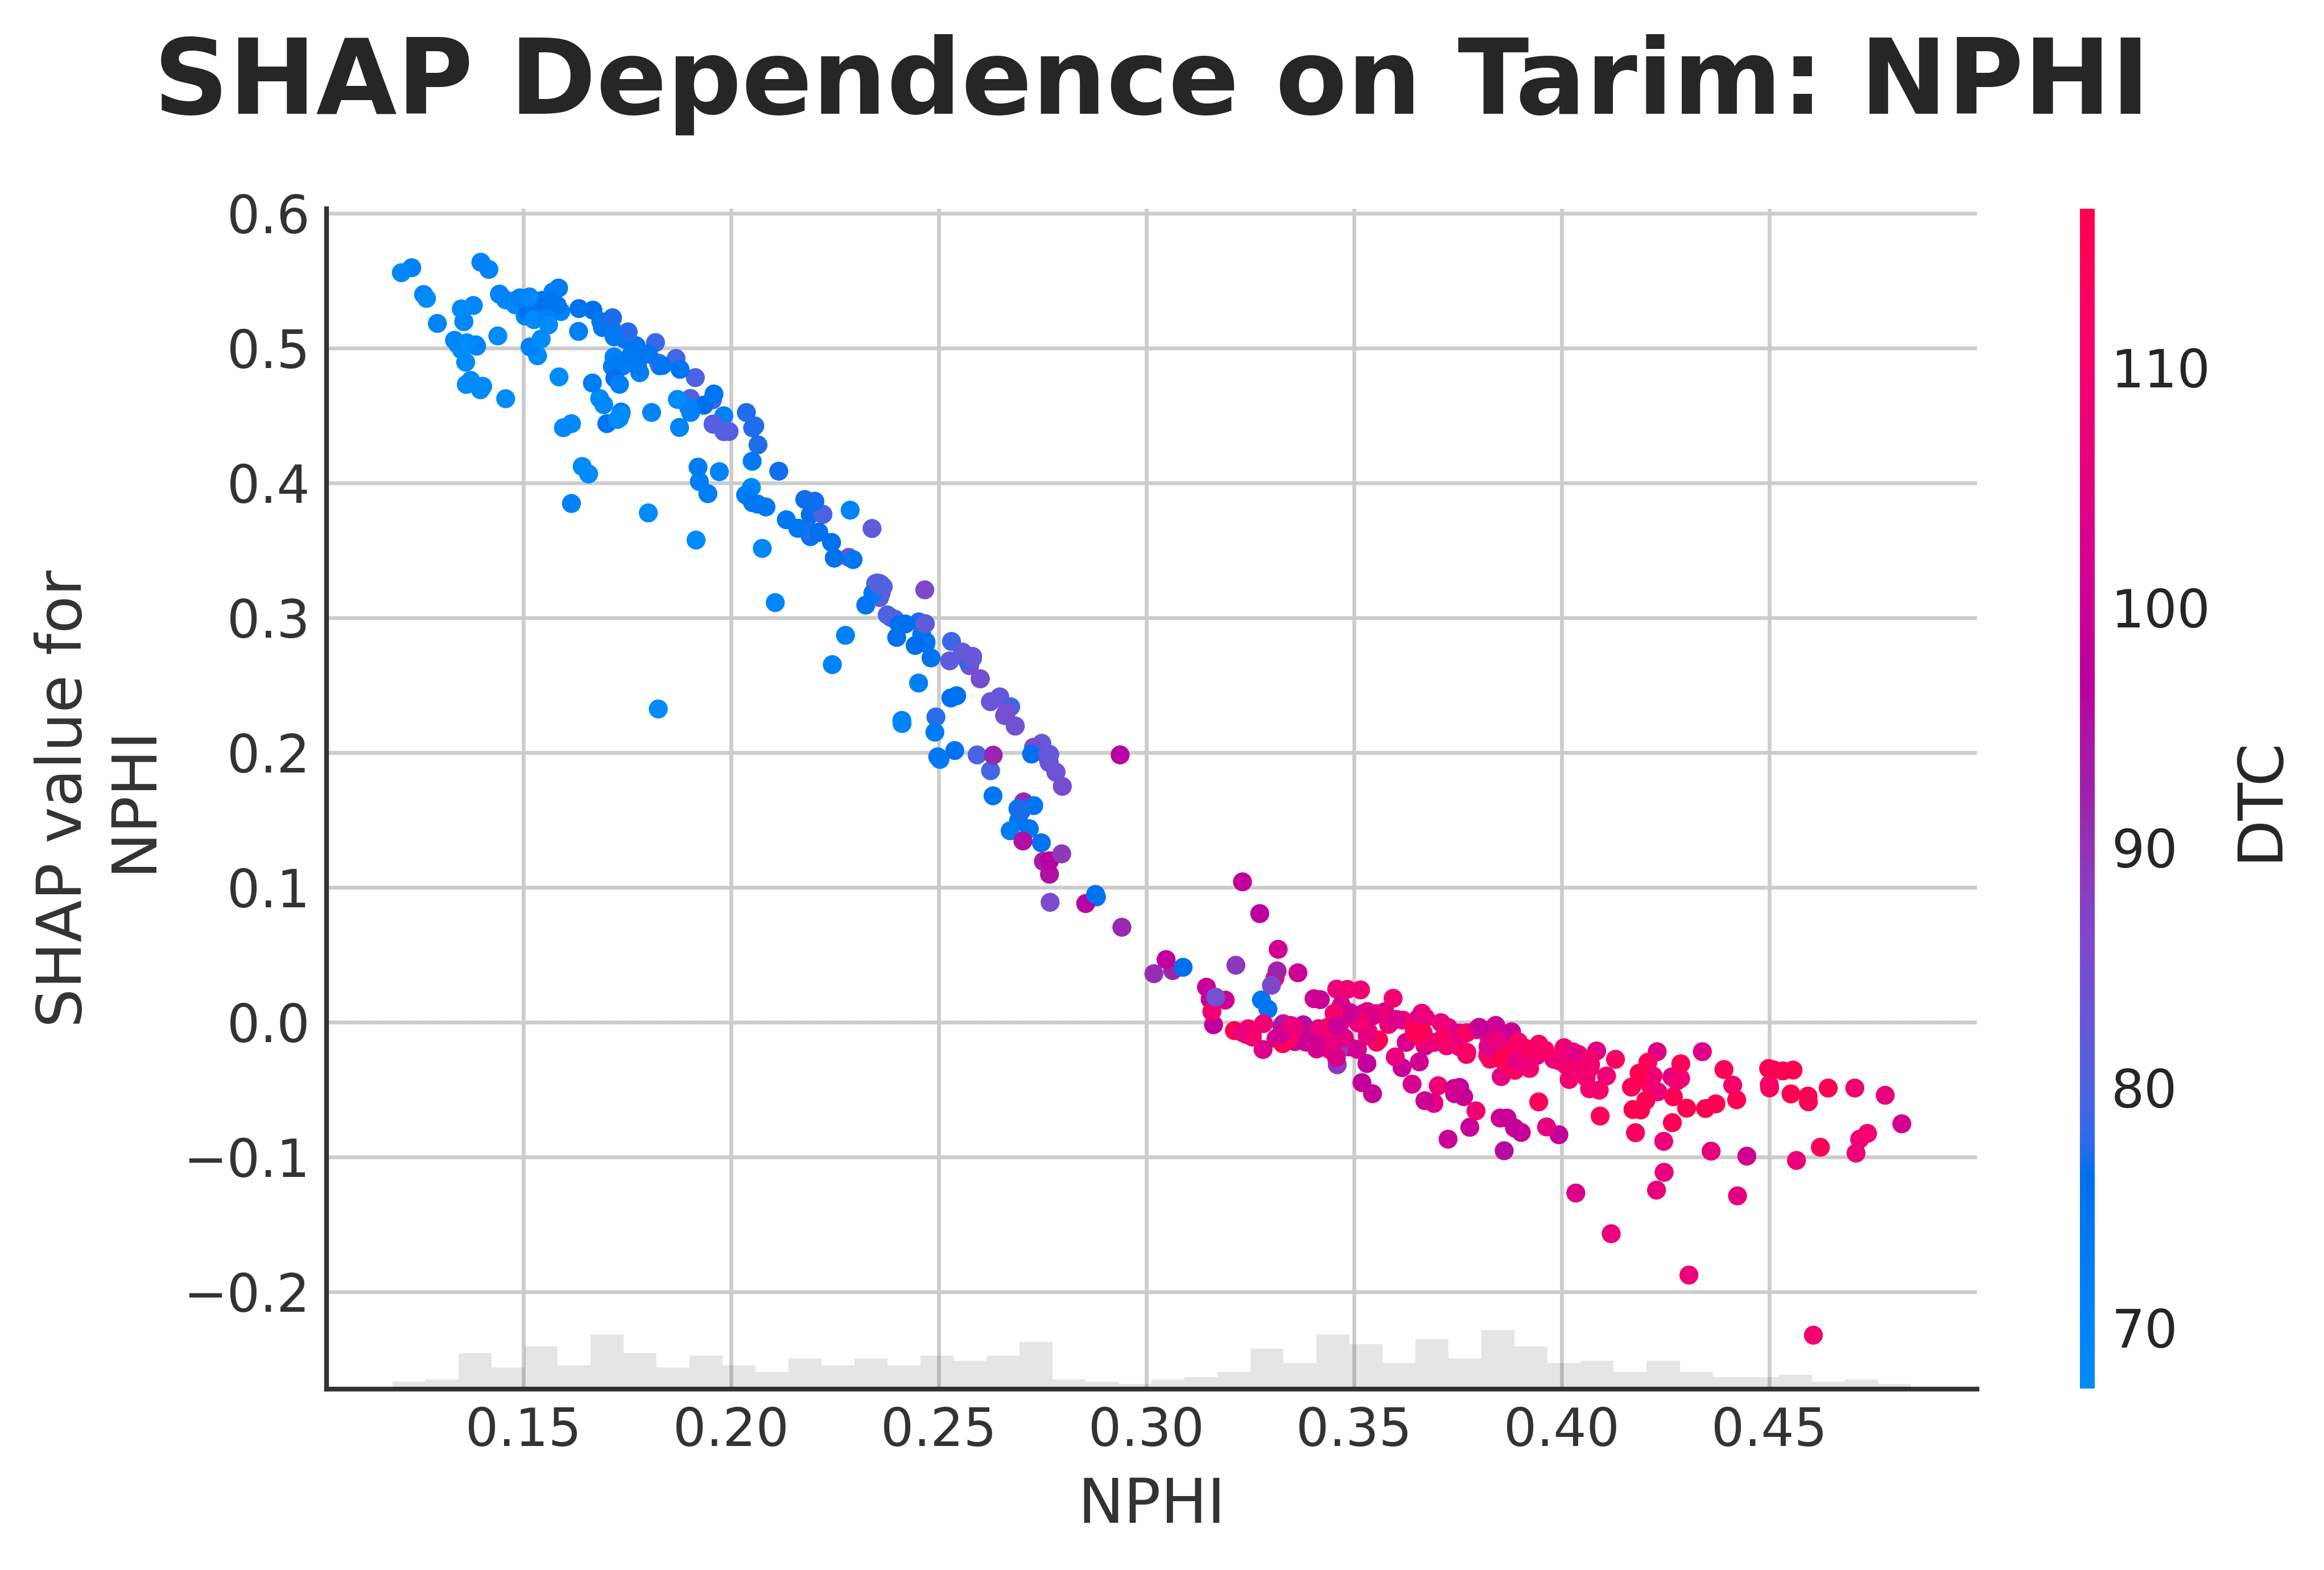

<Figure size 8400x2400 with 0 Axes>

In [36]:
if not hasattr(config, 'FIGURE_DIR'): config.FIGURE_DIR = "../figures"
explain_dir = os.path.join(config.FIGURE_DIR, "explainability")
if not os.path.exists(explain_dir): os.makedirs(explain_dir)

# 1. SHAP Summary Plot
print("Generating 1/6: SHAP Summary Plot...")
fig1 = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, show=False, plot_size=(10, 6))
plt.title(f"SHAP Summary (Tarim Dataset | {CHAMP_MODEL_NAME})", fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(explain_dir, "9a_shap_summary_tarim.png"), dpi=600, bbox_inches='tight')
plt.close(fig1)

# 2. SHAP Bar Plot 
print("Generating 2/6: SHAP Bar Plot (Global Feature Importance)...")
fig_bar = plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, show=False)
plt.title(f"SHAP Global Feature Importance (Tarim Dataset | {CHAMP_MODEL_NAME})", fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(explain_dir, "9b_shap_bar_tarim.png"), dpi=600, bbox_inches='tight')
plt.close(fig_bar)

# 3. SHAP Dependence Plot
print("Generating 3/6: SHAP Dependence Plot...")
mean_shap_values = np.abs(shap_values.values).mean(axis=0)
top_feature_idx = np.argmax(mean_shap_values)
top_feature_name = champ_features[top_feature_idx]

fig2 = plt.figure(figsize=(8, 6))
shap.plots.scatter(shap_values[:, top_feature_name], color=shap_values, show=False)
plt.title(f"SHAP Dependence on Tarim: {top_feature_name}", fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(explain_dir, "10_shap_dependence_tarim.png"), dpi=600, bbox_inches='tight')
plt.close(fig2)

# 4. SHAP Waterfall Plot
print("Generating 4/6: SHAP Waterfall Plot...")
probs = predict_fn(X_explain.values)
best_sample_idx = np.argmax(probs)
prob_val = probs[best_sample_idx]

fig3 = plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[best_sample_idx], show=False)
plt.title(f"Tarim Local Decision (Sample {best_sample_idx} | Prob = {prob_val:.2f})", fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(explain_dir, "11a_shap_waterfall_tarim.png"), dpi=600, bbox_inches='tight')
plt.close(fig3)

# 5. SHAP Force Plot
print("Generating 5/6: SHAP Force Plot...")
fig_force = plt.figure(figsize=(14, 4)) 
shap.plots.force(
    shap_values[best_sample_idx], 
    matplotlib=True, 
    show=False
)
fig_force = plt.gcf()
fig_force.suptitle(f"Tarim Local Decision Force Plot (Sample {best_sample_idx} | Prob = {prob_val:.2f})", fontweight='bold', y=1.1)
plt.savefig(os.path.join(explain_dir, "11b_shap_force_tarim.png"), dpi=600, bbox_inches='tight', pad_inches=0.5)
plt.close(fig_force)

# 6. Reservoir Probability Histogram
print("Generating 6/6: Reservoir Probability Histogram (Tarim)...")
fig4 = plt.figure(figsize=(10, 6))
plot_df = pd.DataFrame({"prob": tarim_probs, "target": np.where(y_tarim_true == 1, "Reservoir", "Non-Reservoir")})
import seaborn as sns
sns.histplot(data=plot_df, x="prob", hue="target", palette={"Non-Reservoir": "gray", "Reservoir": "green"}, element="step", stat="density", common_norm=False, bins=30, alpha=0.6)
plt.axvline(x=CHAMP_THRESH, color='red', linestyle='--', linewidth=2.5, label=f'Threshold ({CHAMP_THRESH:.2f})')
plt.title('Prediction Confidence on Tarim Basin (Blind Test)', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Predicted Probability of Reservoir')
plt.ylabel('Density')
plt.legend(loc='upper center')
plt.tight_layout()
plt.savefig(os.path.join(explain_dir, "12_tarim_prob_histogram.png"), dpi=600, bbox_inches='tight')
plt.close(fig4)

print("\n Phase 4 Complete! All 6 explainability plots are safely saved.")

<span style="color:red; font-size:28px;">Geological validation and reservoir interval export for RAG-based CCS Screening</span>

Generating Well Log Depth Plot for Tarim Blind Test...
 Found reservoir targets! Zooming in on window: [24 : 324]


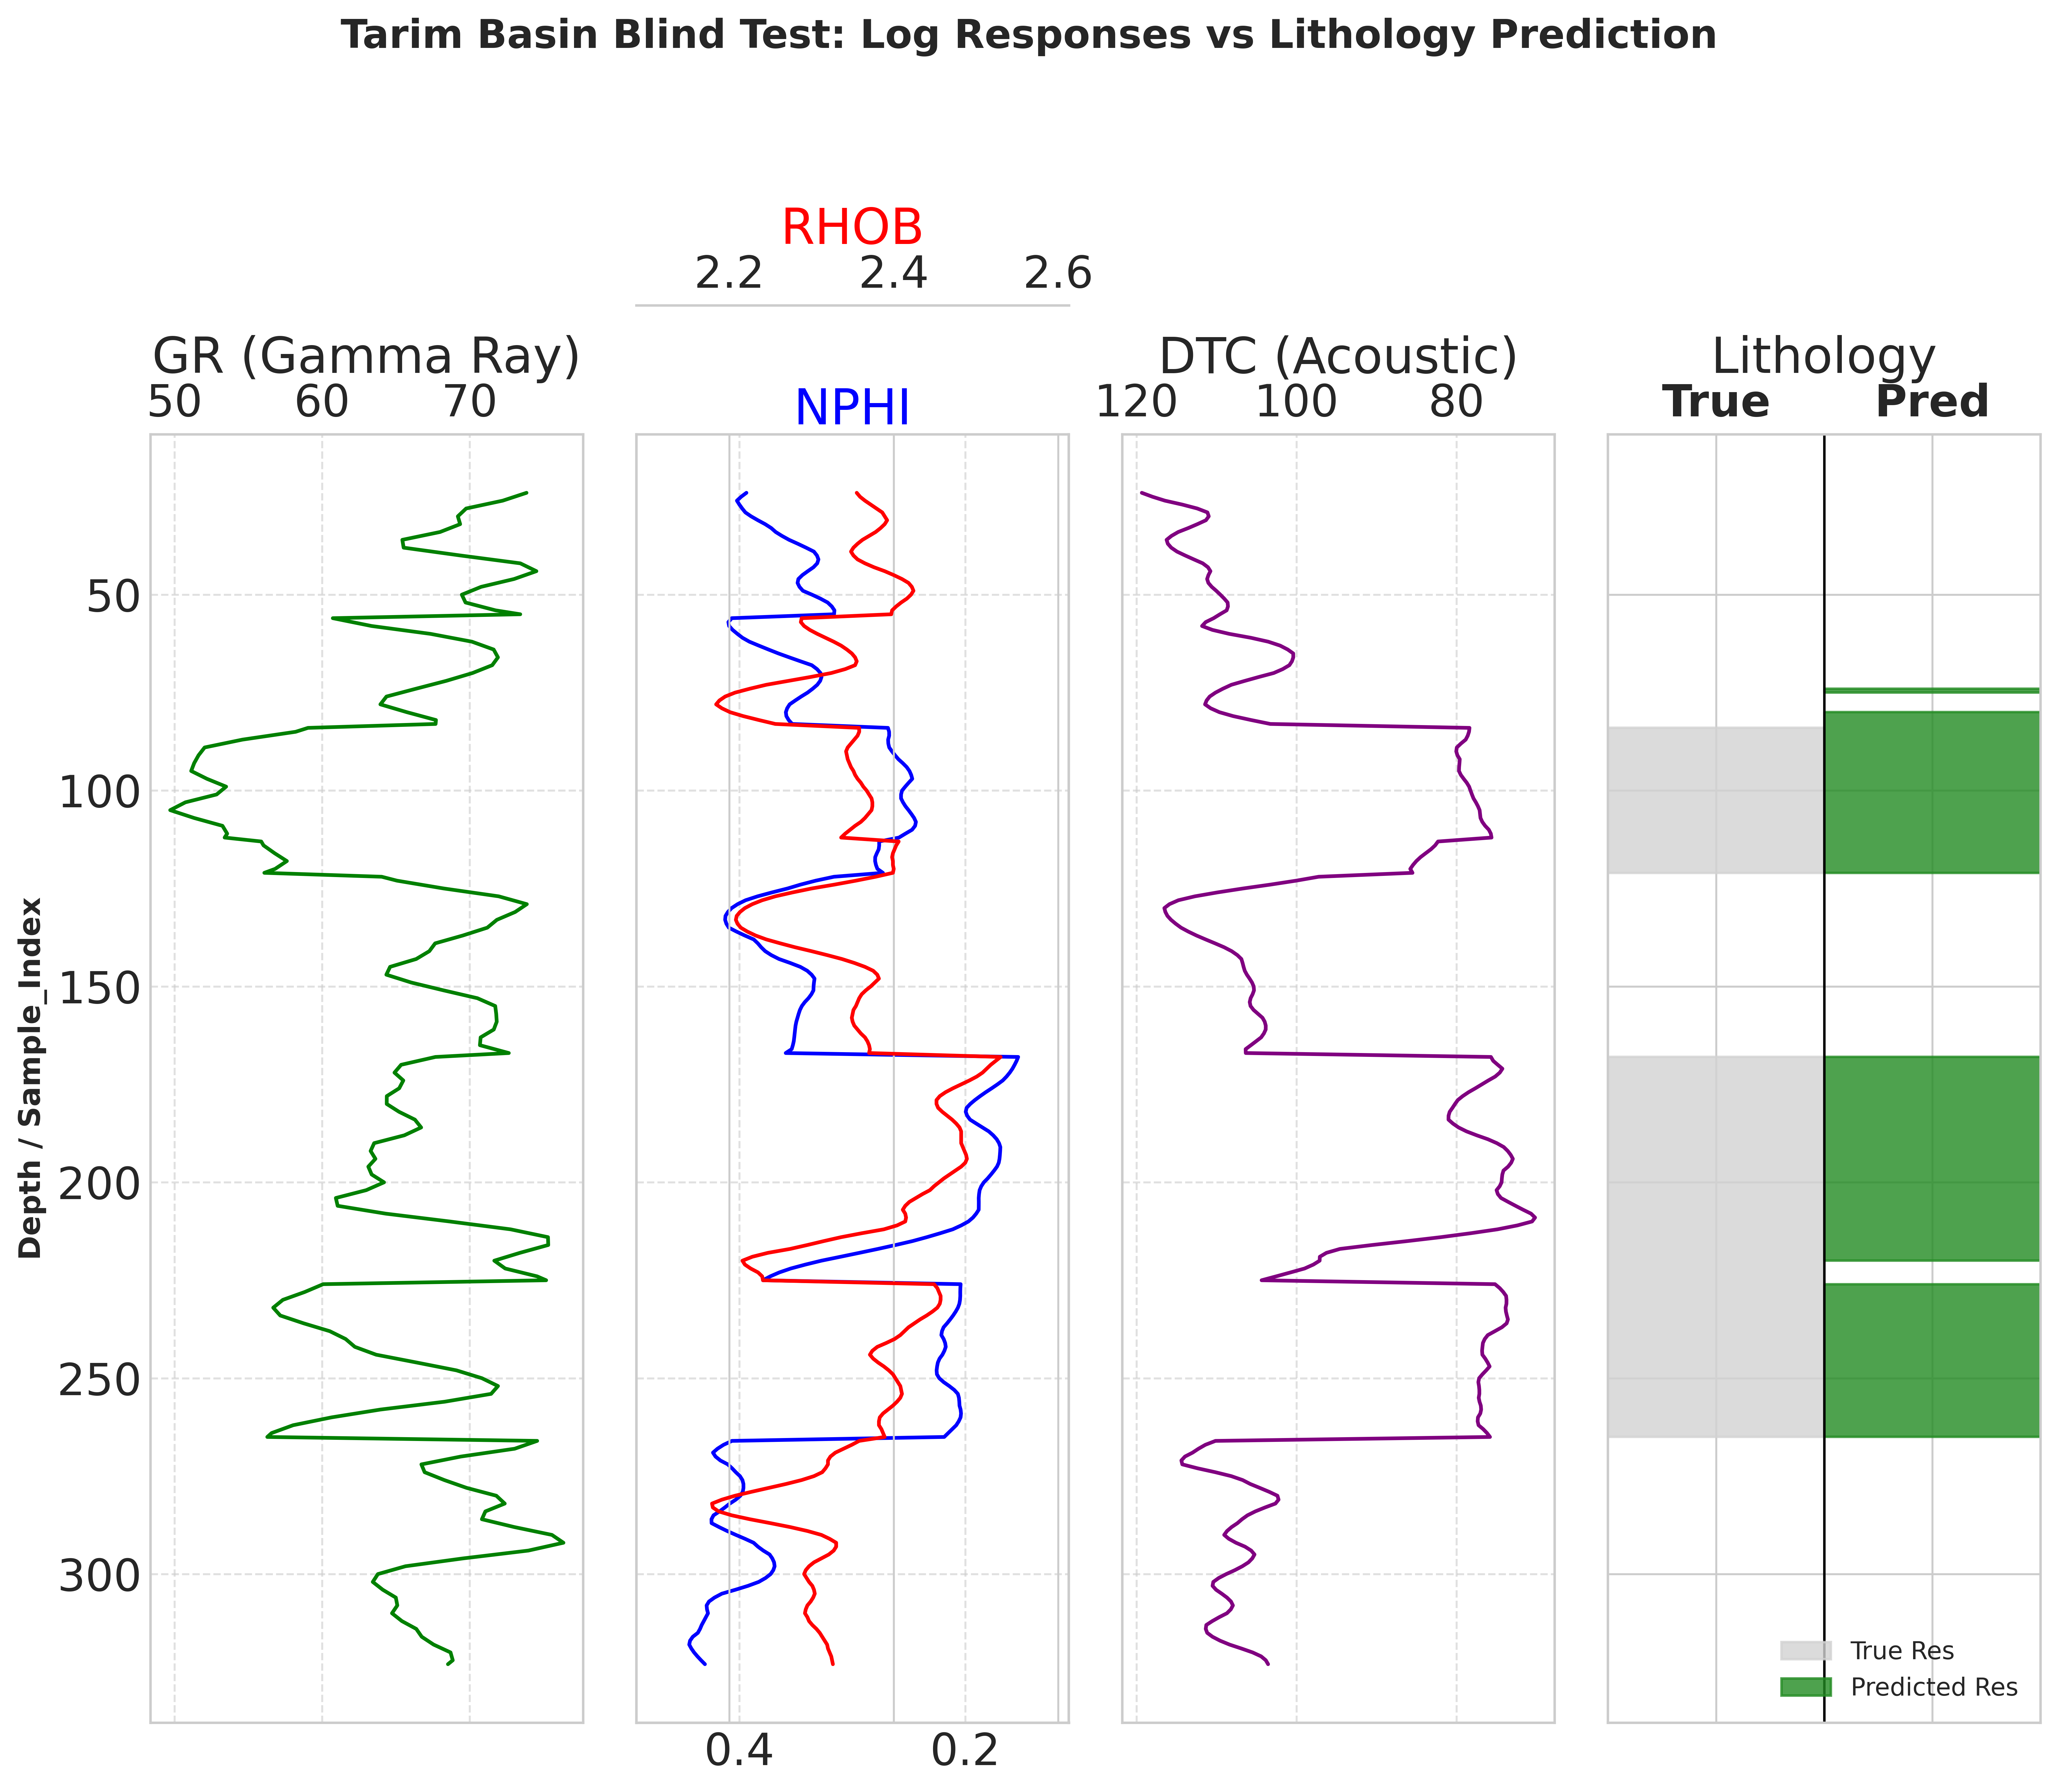

In [37]:
# Well Log Depth Plot
print("Generating Well Log Depth Plot for Tarim Blind Test...")

# determine the depth column
depth_col = 'DEPTH_MD' if 'DEPTH_MD' in tarim_clean.columns else 'Sample_Index'
if depth_col == 'Sample_Index':
    tarim_clean['Sample_Index'] = np.arange(len(tarim_clean))


reservoir_idx = np.where(tarim_preds == 1)[0]
if len(reservoir_idx) > 0:
    center = reservoir_idx[0]
    start = max(center - 50, 0)
    end = min(center + 250, len(tarim_clean))
    print(f" Found reservoir targets! Zooming in on window: [{start} : {end}]")
else:
    start = 0
    end = min(300, len(tarim_clean))
    print(" No strong reservoir signals found, plotting default starting window.")

# extract the data and sort it forcibly by depth
plot_df = tarim_clean.iloc[start:end].copy()
plot_df['predicted_class'] = tarim_preds[start:end]
plot_df['target'] = y_tarim_true[start:end]

plot_df = plot_df.sort_values(depth_col).reset_index(drop=True)
plot_depth = plot_df[depth_col].values
plot_pred = plot_df['predicted_class'].values
plot_true = plot_df['target'].values


fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 10), sharey=True)
fig.suptitle('Tarim Basin Blind Test: Log Responses vs Lithology Prediction', fontsize=16, fontweight='bold', y=1.02)

# Track 1: GR
axes[0].plot(plot_df['GR'], plot_depth, color='green', linewidth=1.5)
axes[0].set_xlabel('GR (Gamma Ray)')
axes[0].xaxis.set_label_position('top'); axes[0].xaxis.tick_top()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Track 2: NPHI & RHOB (Standard Petrophysical Crossover Plot)
axes[1].plot(plot_df['NPHI'], plot_depth, color='blue', linewidth=1.5, label='NPHI')
axes[1].set_xlabel('NPHI', color='blue')
axes[1].xaxis.set_label_position('top')
axes[1].xaxis.tick_top()

# NPHI must reverse the X-axis (decreasing from right to left)
axes[1].invert_xaxis() 
axes[1].grid(True, linestyle='--', alpha=0.6)

# Two-axis plotting of RHOB
ax1_twin = axes[1].twiny()
ax1_twin.plot(plot_df['RHOB'], plot_depth, color='red', linewidth=1.5, label='RHOB')
ax1_twin.set_xlabel('RHOB', color='red')
ax1_twin.xaxis.set_label_position('top')
ax1_twin.xaxis.tick_top()
ax1_twin.spines['top'].set_position(('axes', 1.10))
ax1_twin.spines['top'].set_visible(True)
nphi_min, nphi_max = plot_df['NPHI'].quantile(0.01), plot_df['NPHI'].quantile(0.99)
rhob_min, rhob_max = plot_df['RHOB'].quantile(0.01), plot_df['RHOB'].quantile(0.99)
axes[1].set_xlim(nphi_max + 0.05, nphi_min - 0.05) 
ax1_twin.set_xlim(rhob_min - 0.1, rhob_max + 0.1)

# Track 3: DTC (if exists)
if 'DTC' in plot_df.columns:
    axes[2].plot(plot_df['DTC'], plot_depth, color='purple', linewidth=1.5)
    axes[2].set_xlabel('DTC (Acoustic)')
axes[2].xaxis.set_label_position('top'); axes[2].xaxis.tick_top()
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].invert_xaxis()

# Track 4: True compared with Predicted Lithology
axes[3].fill_betweenx(plot_depth, 0, 0.5, where=(plot_true==1), color='lightgray', label='True Res', alpha=0.8)
axes[3].fill_betweenx(plot_depth, 0.5, 1.0, where=(plot_pred==1), color='forestgreen', label='Predicted Res', alpha=0.8)
axes[3].set_xlim(0, 1)
axes[3].set_xticks([0.25, 0.75])
axes[3].set_xticklabels(['True', 'Pred'], fontweight='bold')
axes[3].set_xlabel('Lithology')
axes[3].xaxis.set_label_position('top'); axes[3].xaxis.tick_top()
axes[3].axvline(0.5, color='black', linewidth=1) 
axes[3].legend(loc='lower right', fontsize=10)

axes[0].invert_yaxis() 
axes[0].set_ylabel(f'Depth / {depth_col}', fontweight='bold', fontsize=12)

plt.tight_layout()
depth_plot_path = os.path.join(config.FIGURE_DIR, "13_tarim_depth_plot.png")
plt.savefig(depth_plot_path, dpi=600, bbox_inches='tight')
plt.show(); plt.close(fig)

In [38]:
import json

print("\n Extracting continuous reservoir intervals for RAG system (Feature-Enriched Version)...")

# Ensure consistency in the depth column
depth_col = 'DEPTH_MD' if 'DEPTH_MD' in tarim_clean.columns else 'Sample_Index'
if depth_col == 'Sample_Index' and 'Sample_Index' not in tarim_clean.columns:
    tarim_clean['Sample_Index'] = np.arange(len(tarim_clean))
    print(" 'DEPTH_MD' not found. Created 'Sample_Index' for thickness calculation.")

# Prepare the predictive data
tarim_clean['predicted_prob'] = tarim_probs
tarim_clean['predicted_class'] = tarim_preds

intervals = []
in_reservoir = False
start_idx = 0
start_depth = 0
thickness_unit = "samples" if depth_col == 'Sample_Index' else "meters"

df_for_extraction = tarim_clean.reset_index(drop=True)

# Identify the core physical characteristic columns and prepare to calculate the average values.
features_to_extract = [col for col in champ_features if col in df_for_extraction.columns]

for i, row in df_for_extraction.iterrows():
    is_res = row['predicted_class'] == 1
    
    if is_res and not in_reservoir:
        in_reservoir = True
        start_idx = i
        start_depth = row[depth_col]
        
    elif not is_res and in_reservoir:
        in_reservoir = False
        end_depth = df_for_extraction.loc[i-1, depth_col]
        
        thickness = (i - start_idx) if depth_col == 'Sample_Index' else (end_depth - start_depth)
        
        # Extract all data subsets of this layer section
        interval_data = df_for_extraction.loc[start_idx:i-1]
        avg_prob = interval_data['predicted_prob'].mean()
        
        # Calculate the average value of the core logging characteristics for this layer section
        avg_petrophysics = {}
        for feature in features_to_extract:
            avg_petrophysics[f"avg_{feature}"] = float(round(interval_data[feature].mean(), 3))
        
        if (i - start_idx) >= 5:
            intervals.append({
                "interval_id": f"Tarim_Target_{len(intervals)+1}",
                "basin": "Tarim Basin",
                "top_depth": float(round(start_depth, 2)),
                "bottom_depth": float(round(end_depth, 2)),
                "thickness": float(round(thickness, 2)),
                "thickness_unit": thickness_unit,
                "average_confidence": float(round(avg_prob, 4)),
                "petrophysical_signatures": avg_petrophysics, 
                "dominant_lithology": "Sandstone/Carbonate (Predicted Reservoir)"
            })

# Handle the logic for end protection.
if in_reservoir:
    last_idx = len(df_for_extraction) - 1
    end_depth = df_for_extraction.loc[last_idx, depth_col]
    
    thickness = (len(df_for_extraction) - start_idx) if depth_col == 'Sample_Index' else (end_depth - start_depth)
    
    interval_data = df_for_extraction.loc[start_idx:last_idx]
    avg_prob = interval_data['predicted_prob'].mean()
    
    avg_petrophysics = {}
    for feature in features_to_extract:
        avg_petrophysics[f"avg_{feature}"] = float(round(interval_data[feature].mean(), 3))
    
    if (len(df_for_extraction) - start_idx) >= 5:
        intervals.append({
            "interval_id": f"Tarim_Target_{len(intervals)+1}",
            "basin": "Tarim Basin",
            "top_depth": float(round(start_depth, 2)),
            "bottom_depth": float(round(end_depth, 2)),
            "thickness": float(round(thickness, 2)),
            "thickness_unit": thickness_unit,
            "average_confidence": float(round(avg_prob, 4)),
            "petrophysical_signatures": avg_petrophysics, 
            "dominant_lithology": "Sandstone/Carbonate (Predicted Reservoir)"
        })

# Export JSON
if 'REPORT_DIR' not in locals():
    REPORT_DIR = "../reports"
if not os.path.exists(REPORT_DIR):
    os.makedirs(REPORT_DIR)

rag_input_path = os.path.join(REPORT_DIR, "rag_target_intervals.json")
with open(rag_input_path, 'w') as f:
    json.dump({"identified_ccs_targets": intervals}, f, indent=4)

print(f" RAG Bridge created! Successfully extracted {len(intervals)} potential CCS target intervals.")
print(f" JSON payload saved to: {rag_input_path}")
print("\n ML PIPELINE COMPLETELY FINISHED! YOU ARE READY TO BUILD THE RAG SYSTEM. ")


 Extracting continuous reservoir intervals for RAG system (Feature-Enriched Version)...
 RAG Bridge created! Successfully extracted 20 potential CCS target intervals.
 JSON payload saved to: ../reports/rag_target_intervals.json

 ML PIPELINE COMPLETELY FINISHED! YOU ARE READY TO BUILD THE RAG SYSTEM. 
